|  |  |  |
|---|---|---|
| |**Final Project Report** |
| |**Title: Optimizing Urban Mobility through Cab Data Analytics** |

|  |  |  |
|---|---|---|
|| **Project Group** |
| Anushka Sarath | A20576979 | asarath@hawk.iit.edu |
| Lokesh Sambireddygari | A20536430 | lsambireddygari@hawk.iit.edu |
| Anantha Sai Valluru | A20552446 | valluru1@hawk.iit.edu |

|  |  |  |
|---|---|---|
| |**Project Group Leader:** |
| Anushka Sarath | A20576979 | asarath@hawk.iit.edu |

# **Abstract**

This report delivers an in-depth evaluation of three machine-learning approaches—Linear Regression, Decision Trees, and Random Forests—to forecast ride-sharing fares for Uber and Lyft. We incorporated features such as trip distance and duration, weather variables, and service category to build models that capture each provider’s pricing dynamics.

Our Linear Regression models leveraged straightforward, efficient relationships between predictors and price, performing especially well for Uber’s fare structure. Decision Trees offered clear, interpretable splits but were prone to overfitting, which weakened their accuracy on Lyft data. In contrast, Random Forests handled complex feature interactions more robustly and emerged as the top performer for Lyft predictions.

By comparing these techniques across multiple error metrics, we uncovered distinct strengths and limitations for each algorithm and service. These findings inform practitioners’ choice of model based on trade-offs between simplicity, interpretability, and predictive power—and suggest avenues for refining fare-prediction tools moving forward.

## Overview

**Problem Statement:**  
This study examines how Uber and Lyft set their prices and how factors like weather affect both pricing and ride demand across their platforms.

**Literature Review:**  
- **Shashank H. (2020):** Analyzes massive volumes of trip data from Uber and Lyft, applying regression techniques and machine learning to forecast fares by accounting for variables such as weather and surge pricing, aiming to give riders more accurate pre-trip cost estimates.  
- **Jiang et al. (2018):** Compares Uber, Lyft, and traditional taxis in San Francisco and New York City using spatial lag models and point-pattern analysis. Their work explores differences in supply, demand, pricing, wait times, and how these services integrate with urban infrastructure and socio-economic characteristics.  
- **Jingyu Sun (2022):** Investigates market strategies of Uber and Lyft, focusing on the mechanics of surge pricing, its influence on driver availability and rider behavior, and contrasts these dynamics with those of conventional taxi services, while highlighting the platforms’ technological and regulatory hurdles.

## **Data Preparation**

**Pipeline Overview:**  
We designed a preprocessing workflow to clean and harmonize our dataset for reliable modeling.

**Addressing Missing Values & Inconsistencies:**  
- Source and destination fields had many blanks and mismatched labels.  
- We standardized naming conventions and filled gaps to ensure consistency across all records.

**Unifying Date–Time Formats:**  
- Original files used different timestamp styles, complicating joins.  
- We converted every date-time field to a single, consistent format for seamless integration.

**Aligning Data Types:**  
- Identical features appeared with varying types (e.g., strings vs. dates) in different tables.  
- We normalized each feature’s type across all sources to avoid processing errors.

**Feature Engineering:**  
- Computed trip duration wherever it was missing by subtracting start from end times.  
- Derived the day of week from trip dates to add temporal context.  
- Dropped columns not shared by every file (e.g., SunriseTime, SunsetTime, MoonPhase).  
- Used latitude/longitude to backfill any remaining missing source or destination entries.

**Merging Weather Data:**  
- Weather records initially used a different date format than ride data.  
- We reformatted weather dates to align with trip records, ensuring accurate feature matching.

After these steps, our cleaned dataset contains 23 unified features ready for analysis.

# **Data Analysis**

The following are the 23 relevant features after the data preprocessing:



|  |  |  |  |
|---|---|---|---|
| Fri | Lyft XL | UberPool | Partly Cloudy |
| Sat | Lux Black XL | UberXL | WAV |
| Sun | Lux Black | Black | Possible Drizzle |
| Shared | surge_multiplier | Black SUV | Overcast |
| Mostly Cloudy | Drizzle | Rain | Light Rain |
| distance | Partly Cloudy | Foggy | - |

In [1]:
# Install packages from CRAN
install.packages(c("caret", "sqldf", "tidyr", "tidyverse", "ggplot2", "readr", "gmodels", "tm",
                   "SnowballC", "wordcloud", "RColorBrewer", "treemap", "highcharter", "remotes",
                   "corrplot", "rpart.plot", "magrittr", "dplyr", "igraph", "pillar", "repr",
                   "lifecycle", "ellipsis", "htmltools", "vctrs", "lubridate", "Rtsne", "umap", "rlang"))

# Install packages from specific sources or GitHub
remotes::install_github("jbkunst/highcharter")

# Load libraries
library(caret)
library(sqldf)
library(tidyr)
library(tidyverse)
library(ggplot2)
library(readr)
library(gmodels)
library(tm)
library(SnowballC)
library(wordcloud)
library(RColorBrewer)
library(treemap)
library(highcharter)
library(corrplot)
library(rpart.plot)
library(magrittr)
library(dplyr)
library(igraph)
library(pillar)
library(repr)
library(lifecycle)
library(ellipsis)
library(htmltools)
library(vctrs)
library(lubridate)
library(Rtsne)
library(umap)

Installing packages into 'C:/Users/ANUSHKA/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'caret' successfully unpacked and MD5 sums checked
package 'sqldf' successfully unpacked and MD5 sums checked
package 'tidyr' successfully unpacked and MD5 sums checked
package 'tidyverse' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked
package 'readr' successfully unpacked and MD5 sums checked
package 'gmodels' successfully unpacked and MD5 sums checked
package 'tm' successfully unpacked and MD5 sums checked
package 'SnowballC' successfully unpacked and MD5 sums checked
package 'wordcloud' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked
package 'treemap' successfully unpacked and MD5 sums checked
package 'highcharter' successfully unpacked and MD5 sums checked
package 'remotes' successfully unpacked and MD5 sums checked
package 'corrplot' successfully unpacked and MD5 sums checked
package 'rpart.plot' successfully unpacked and MD5 sums checked
package 'magrittr'

Warning message:
"cannot remove prior installation of package 'htmltools'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\00LOCK\htmltools\libs\x64\htmltools.dll to C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\htmltools\libs\x64\htmltools.dll: Permission denied"
Warning message:
"restored 'htmltools'"


package 'vctrs' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'vctrs'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\00LOCK\vctrs\libs\x64\vctrs.dll to C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\vctrs\libs\x64\vctrs.dll: Permission denied"
Warning message:
"restored 'vctrs'"


...

Warning message:
"cannot remove prior installation of package 'rlang'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\00LOCK\rlang\libs\x64\rlang.dll to C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\rlang\libs\x64\rlang.dll: Permission denied"
Warning message:
"restored 'rlang'"



The downloaded binary packages are in
	C:\Users\ANUSHKA\AppData\Local\Temp\Rtmp8aIcOH\downloaded_packages


Running `R CMD build`...



* checking for file 'C:\Users\ANUSHKA\AppData\Local\Temp\Rtmp8aIcOH\remotes83145a1526ab\jbkunst-highcharter-b9d4e71/DESCRIPTION' ... OK
* preparing 'highcharter':
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Removed empty directory 'highcharter/vignettes'
  NB: this package now depends on R (>= 4.1.0)
  pipe |> or function shorthand \(...) syntax added in R 4.1.0.
  File(s) using such syntax:
    'data_to_boxplot.Rd' 'export_hc.Rd' 'hc_add_dependency.Rd'
    'hc_add_series.Rd' 'hc_add_series_list.Rd' 'hc_add_series_map.Rd'
    'hc_add_theme.Rd' 'hc_add_yAxis.Rd' 'hc_annotations.Rd'
    'hc_caption.Rd' 'hc_chart.Rd' 'hc_colorAxis.Rd' 'hc_colors.Rd'
    'hc_credits.Rd' 'hc_drilldown.Rd' 'hc_elementId.Rd' 'hc_exporting.Rd'
    'hc_legend.Rd' 'hc_loading.Rd' 'hc_mapNavigation.Rd'
    'hc_navigator.Rd' 'hc_pane.Rd' 'hc_plotOptions.Rd'
    'hc_rangeSelector.Rd' 'hc_respons

Installing package into 'C:/Users/ANUSHKA/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

Loading required package: ggplot2

Loading required package: lattice

Loading required package: gsubfn

Loading required package: proto

Loading required package: RSQLite

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: NLP


Attaching package: 'NLP'


The following object is masked from 'package:ggplot2':

    annotate


Loading required package: RColorBrewer

Highcharts (www.highcharts.com) is

In [2]:
install.packages("rlang")

Installing package into 'C:/Users/ANUSHKA/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'rlang' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'rlang'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\00LOCK\rlang\libs\x64\rlang.dll to C:\Users\ANUSHKA\AppData\Local\R\win-library\4.5\rlang\libs\x64\rlang.dll: Permission denied"
Warning message:
"restored 'rlang'"



The downloaded binary packages are in
	C:\Users\ANUSHKA\AppData\Local\Temp\Rtmp8aIcOH\downloaded_packages


In [6]:
install.packages("dplyr")

Warning message:
"package 'dplyr' is in use and will not be installed"


In [1]:
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
cabDataSet <- read.csv("rideshare_kaggle.csv")

In [3]:
summary(cabDataSet)

      id              timestamp              hour            day       
 Length:693071      Min.   :1.543e+09   Min.   : 0.00   Min.   : 1.00  
 Class :character   1st Qu.:1.543e+09   1st Qu.: 6.00   1st Qu.:13.00  
 Mode  :character   Median :1.544e+09   Median :12.00   Median :17.00  
                    Mean   :1.544e+09   Mean   :11.62   Mean   :17.79  
                    3rd Qu.:1.545e+09   3rd Qu.:18.00   3rd Qu.:28.00  
                    Max.   :1.545e+09   Max.   :23.00   Max.   :30.00  
                                                                       
     month         datetime           timezone            source         
 Min.   :11.00   Length:693071      Length:693071      Length:693071     
 1st Qu.:11.00   Class :character   Class :character   Class :character  
 Median :12.00   Mode  :character   Mode  :character   Mode  :character  
 Mean   :11.59                                                           
 3rd Qu.:12.00                                        

In [4]:
# Basic overview
totalRows   <- nrow(cabDataSet)
totalCols   <- ncol(cabDataSet)

summaryInfo <- data.frame(
  DatasetName        = "rideshare_kaggle.csv",
  DatasetDescription = "Uber and Lyft ride records for Boston, MA",
  Record_Count       = totalRows,
  Attribute_Count    = totalCols
)

In [5]:
print(summaryInfo)

           DatasetName                        DatasetDescription Record_Count
1 rideshare_kaggle.csv Uber and Lyft ride records for Boston, MA       693071
  Attribute_Count
1              57


In [6]:
# Display the summary information
View(summaryInfo)

DatasetName,DatasetDescription,Record_Count,Attribute_Count
<chr>,<chr>,<int>,<int>
rideshare_kaggle.csv,"Uber and Lyft ride records for Boston, MA",693071,57


In [7]:
str(cabDataSet)

'data.frame':	693071 obs. of  57 variables:
 $ id                         : chr  "424553bb-7174-41ea-aeb4-fe06d4f4b9d7" "4bd23055-6827-41c6-b23b-3c491f24e74d" "981a3613-77af-4620-a42a-0c0866077d1e" "c2d88af2-d278-4bfd-a8d0-29ca77cc5512" ...
 $ timestamp                  : num  1.54e+09 1.54e+09 1.54e+09 1.54e+09 1.54e+09 ...
 $ hour                       : int  9 2 1 4 3 18 5 19 6 10 ...
 $ day                        : int  16 27 28 30 29 17 26 2 3 27 ...
 $ month                      : int  12 11 11 11 11 12 11 12 12 11 ...
 $ datetime                   : chr  "2018-12-16 09:30:07" "2018-11-27 02:00:23" "2018-11-28 01:00:22" "2018-11-30 04:53:02" ...
 $ timezone                   : chr  "America/New_York" "America/New_York" "America/New_York" "America/New_York" ...
 $ source                     : chr  "Haymarket Square" "Haymarket Square" "Haymarket Square" "Haymarket Square" ...
 $ destination                : chr  "North Station" "North Station" "North Station" "North Station" ...
 

In [8]:
# Feature metadata
featureInfo <- data.frame(
  FeatureName = c("price", "distance", "time_of_day"),
  DataClass   = c("Numeric", "Numeric", "Character"),
  Notes       = c("Ride fare in USD", "Ride length in miles", "Time of day the ride started")
)

In [9]:
# Print the feature metadata
print(featureInfo)

  FeatureName DataClass                        Notes
1       price   Numeric             Ride fare in USD
2    distance   Numeric         Ride length in miles
3 time_of_day Character Time of day the ride started


In [10]:
colnames(cabDataSet)

[1] "id"                          "timestamp"                  
 [3] "hour"                        "day"                        
 [5] "month"                       "datetime"                   
 [7] "timezone"                    "source"                     
 [9] "destination"                 "cab_type"                   
[11] "product_id"                  "name"                       
[13] "price"                       "distance"                   
[15] "surge_multiplier"            "latitude"                   
[17] "longitude"                   "temperature"                
[19] "apparentTemperature"         "short_summary"              
[21] "long_summary"                "precipIntensity"            
[23] "precipProbability"           "humidity"                   
[25] "windSpeed"                   "windGust"                   
[27] "windGustTime"                "visibility"                 
[29] "temperatureHigh"             "temperatureHighTime"        
[31] "temperatureLow"              "temperatureLowTime"         
[33] "apparentTemperatureHigh"     "apparentTemperatureHighTime"
[35] "apparentTemperatureLow"      "apparentTemperatureLowTime" 
[37] "icon"                        "dewPoint"                   
[39] "pressure"                    "windBearing"                
[41] "cloudCover"                  "uvIndex"                    
[43] "visibility.1"                "ozone"                      
[45] "sunriseTime"                 "sunsetTime"                 
[47] "moonPhase"                   "precipIntensityMax"         
[49] "uvIndexTime"                 "temperatureMin"             
[51] "temperatureMinTime"          "temperatureMax"             
[53] "temperatureMaxTime"          "apparentTemperatureMin"     
[55] "apparentTemperatureMinTime"  "apparentTemperatureMax"     
[57] "apparentTemperatureMaxTime"

**Data Stylized Facts:**

Warning message:
"Removed 55095 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


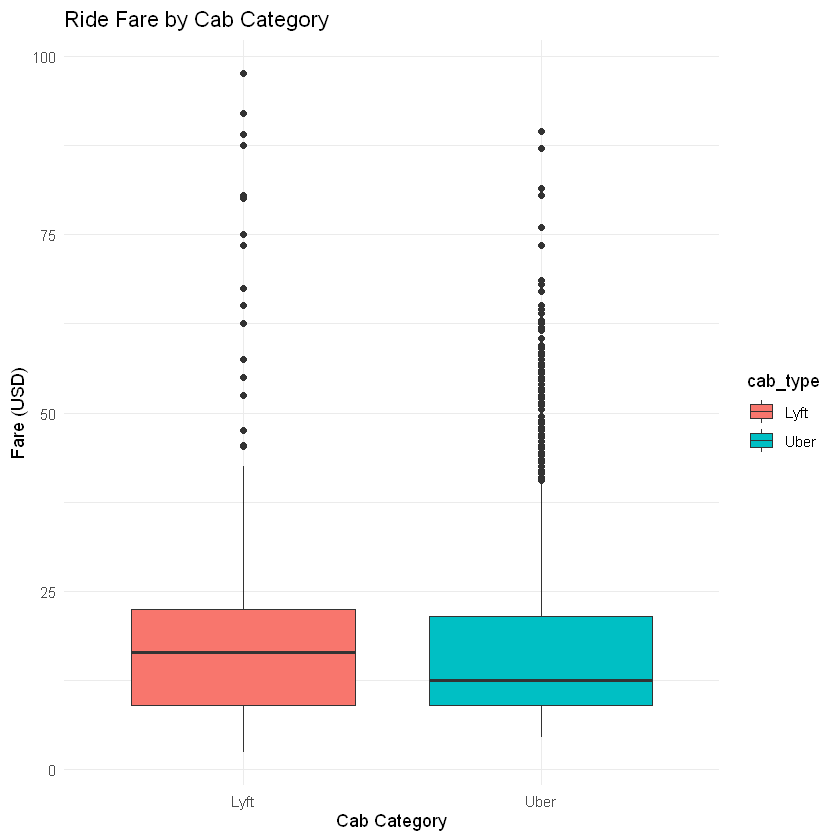

In [11]:
library(ggplot2)

# Boxplot of ride fare by cab category
ggplot(cabDataSet, aes(x = cab_type, y = price, fill = cab_type)) +
  geom_boxplot() +
  labs(
    title = "Ride Fare by Cab Category",
    x     = "Cab Category",
    y     = "Fare (USD)"
  ) +
  theme_minimal()

This figure presents a side-by-side box-and-whisker comparison of Lyft and Uber fares, with Lyft shown in red and Uber in teal. Each box captures the central fare distribution, while individual points denote outliers—rides priced well above or below the typical range. By visualizing these distributions and their extremes, the plot reveals key differences in pricing variability and customer costs between the two platforms.

Warning message:
"Removed 55095 rows containing missing values or values outside the scale range
(`geom_point()`)."


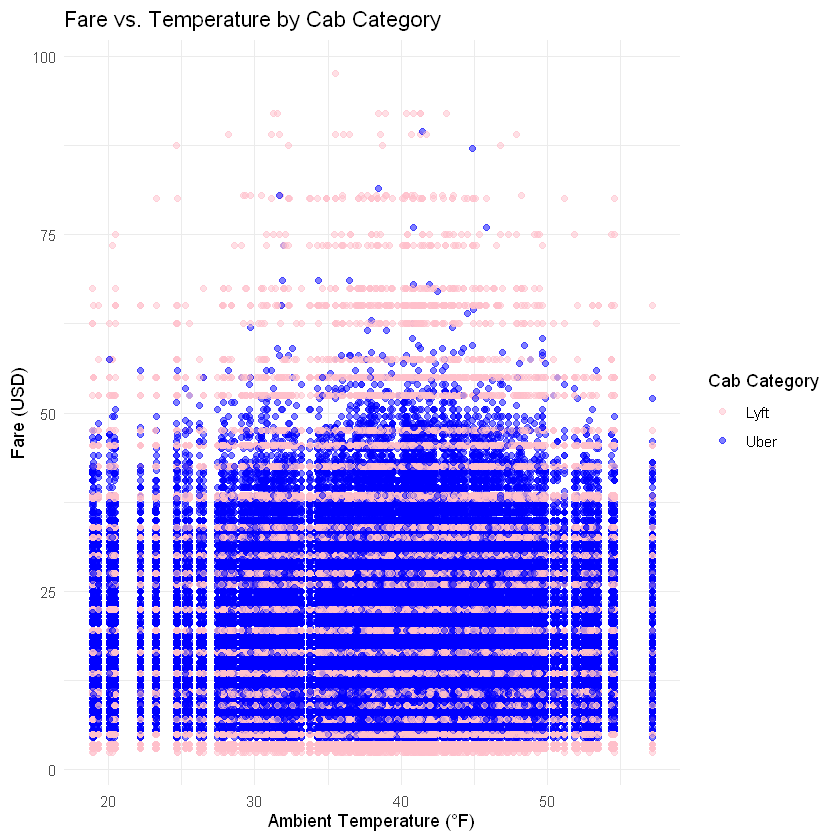

In [13]:
library(ggplot2)

# Scatter plot of fare against ambient temperature by cab category
ggplot(cabDataSet, aes(x = temperature, y = price)) +
  geom_point(aes(color = cab_type), alpha = 0.5) +
  labs(
    title = "Fare vs. Temperature by Cab Category",
    x     = "Ambient Temperature (°F)",
    y     = "Fare (USD)",
    color = "Cab Category"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("Uber" = "blue", "Lyft" = "pink"))

The chart “Price vs. Temperature by Cab Type” plots each ride’s cost (y-axis) against the ambient temperature in °F (x-axis). Pink markers denote Lyft trips, and blue markers denote Uber trips, as shown in the legend. Lyft fares are scattered across a wider price range, while Uber fares tend to cluster at lower prices. Temperatures span roughly 20°F to just over 50°F, and neither service shows a clear link between temperature and cost.


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




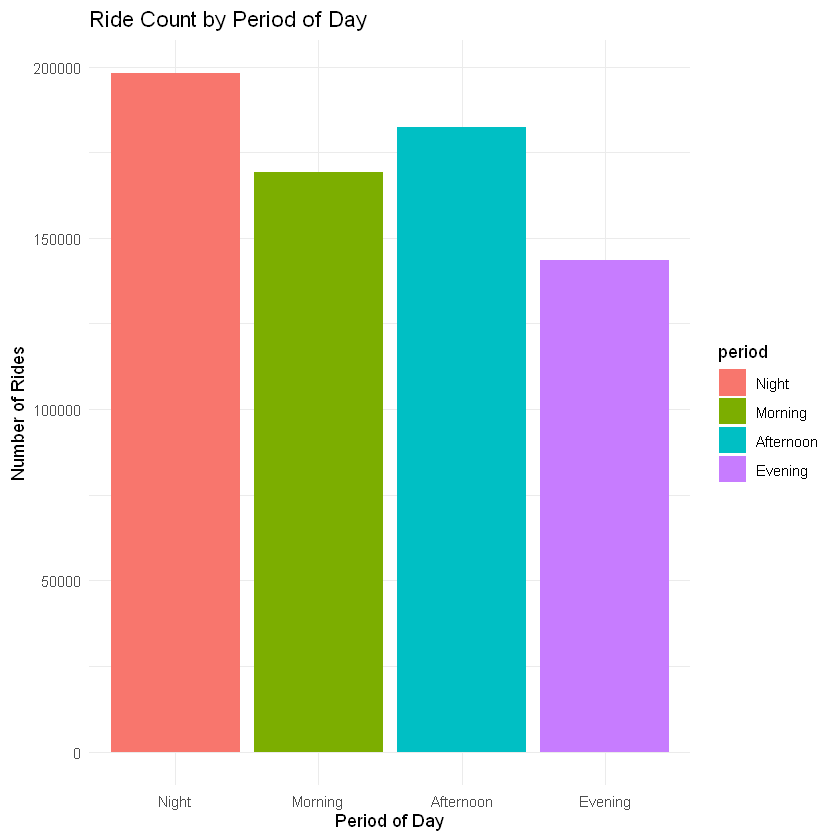

In [14]:
library(lubridate)
library(ggplot2)

cabDataSet %>%
  mutate(
    ride_time  = ymd_hms(datetime),  # convert to POSIXct
    ride_hour  = hour(ride_time),
    period     = cut(
                   ride_hour,
                   breaks = c(0, 6, 12, 18, 24),
                   labels = c("Night", "Morning", "Afternoon", "Evening"),
                   include.lowest = TRUE
                 )
  ) %>%
  count(period) %>%
  ggplot(aes(x = period, y = n, fill = period)) +
  geom_col() +
  labs(
    title = "Ride Count by Period of Day",
    x     = "Period of Day",
    y     = "Number of Rides"
  ) +
  theme_minimal()

This bar chart shows ride counts for night, morning, afternoon, and evening, each period highlighted in a different color. By revealing when demand peaks and dips, it helps providers understand rider behavior and fine-tune their operations and service offerings.

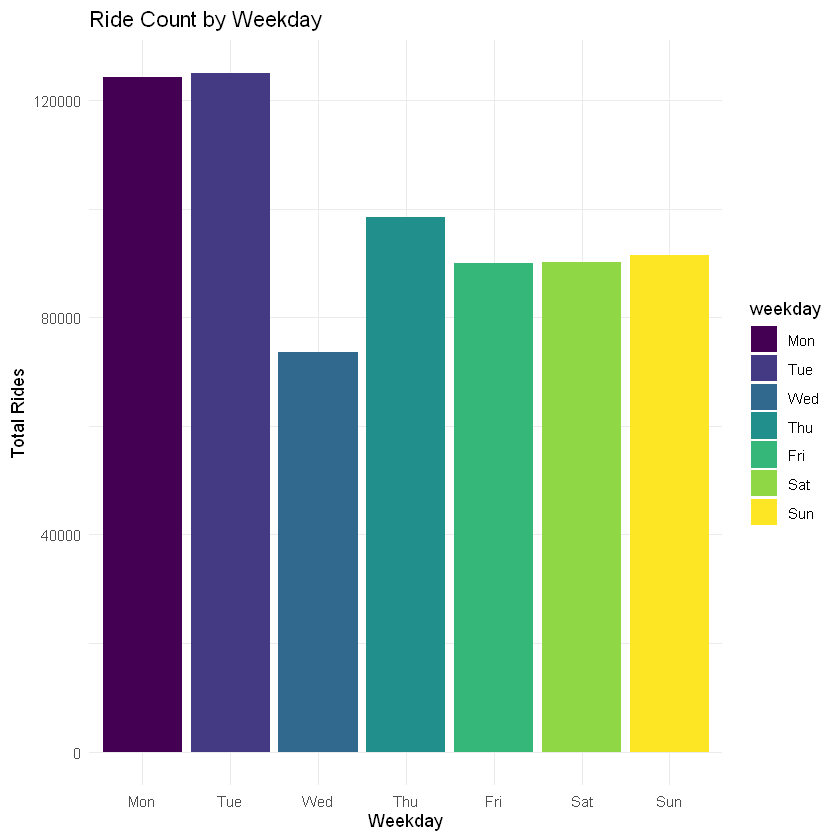

In [15]:
cabDataSet %>%
  mutate(
    ride_ts   = ymd_hms(datetime),                    # ensure POSIXct format
    weekday    = wday(ride_ts, label = TRUE, week_start = 1)  # Monday = 1
  ) %>%
  count(weekday) %>%
  ggplot(aes(x = weekday, y = n, fill = weekday)) +
  geom_col() +
  labs(
    title = "Ride Count by Weekday",
    x     = "Weekday",
    y     = "Total Rides"
  ) +
  theme_minimal()

This chart displays daily ride volumes throughout the week, using distinct colors for each day—ranging from dark purple for Monday to light yellow for Sunday. The y-axis, labeled "Number of Rides," increases in steps of 20,000. Monday and Tuesday lead in ride count, each nearing 120,000 rides, while the remaining days show a gradual decline, with Sunday having the fewest. This visualization offers insights into weekly demand trends for ride-hailing services.

# Exploratory Data Analysis

**Who offers the most rides,Uber or lyft?**

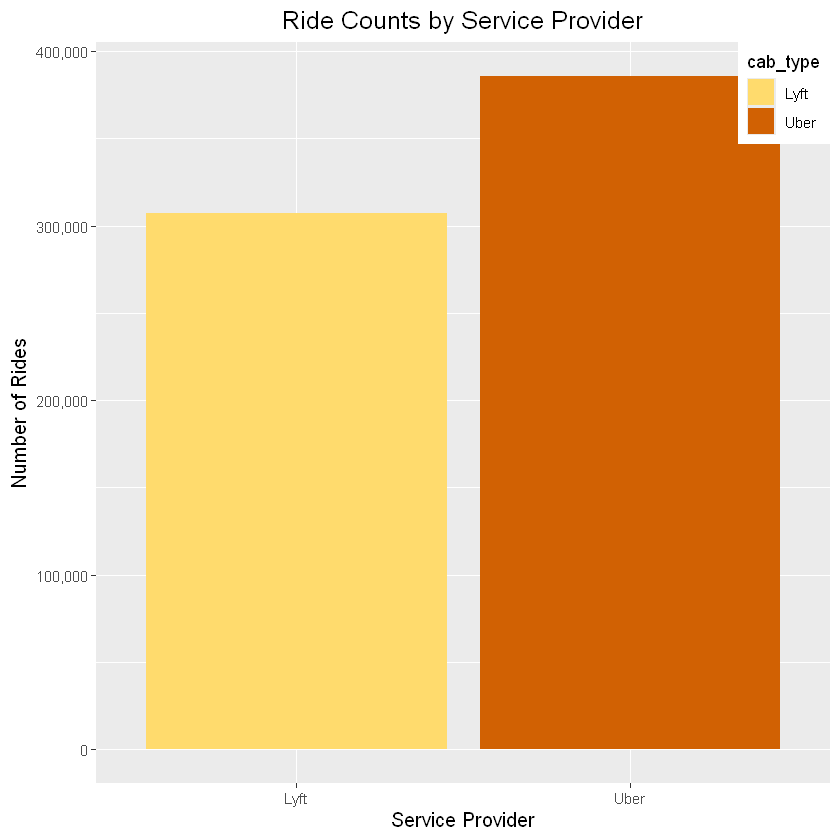

In [21]:
library(dplyr)
library(ggplot2)
library(scales)

# 1. Derive distinct rides by ID
cabDataSet_distinct <- cabDataSet %>%
  distinct(id, .keep_all = TRUE)

# 2. Summarize ride counts and percentages by service
service_summary <- cabDataSet_distinct %>%
  group_by(cab_type) %>%
  summarise(
    total_rides = n(),
    pct_rides   = (n() / nrow(cabDataSet_distinct)) * 100
  )

# 3. Bar chart of ride volume by service provider
ride_volume_plot <- ggplot(cabDataSet_distinct, aes(x = cab_type, fill = cab_type)) +
  geom_bar() +
  scale_y_continuous(
    breaks = seq(0, 1000000, 100000),
    labels = comma
  ) +
  labs(
    title = "Ride Counts by Service Provider",
    x     = "Service Provider",
    y     = "Number of Rides"
  ) +
  theme(
    plot.title           = element_text(size = 15, hjust = 0.5),
    legend.position      = c(1, 1),
    legend.justification = c("right", "top"),
    axis.title           = element_text(size = 12),
    axis.text            = element_text(size = 9),
    plot.caption         = element_text(size = 10)
  ) +
  scale_fill_manual(values = c("#FFDB6D", "#D16103"))

# 4. Render the plot
ride_volume_plot

Lyft's bar is yellow, reaching up to about 175,000 rides. Uber's bar is orange, towering at over 300,000 rides. The chart answers "Who offers the most rides" with Uber clearly in the lead.

**Lyft: Per Surge Multiplier - Total Rides vs Hour of the Day**

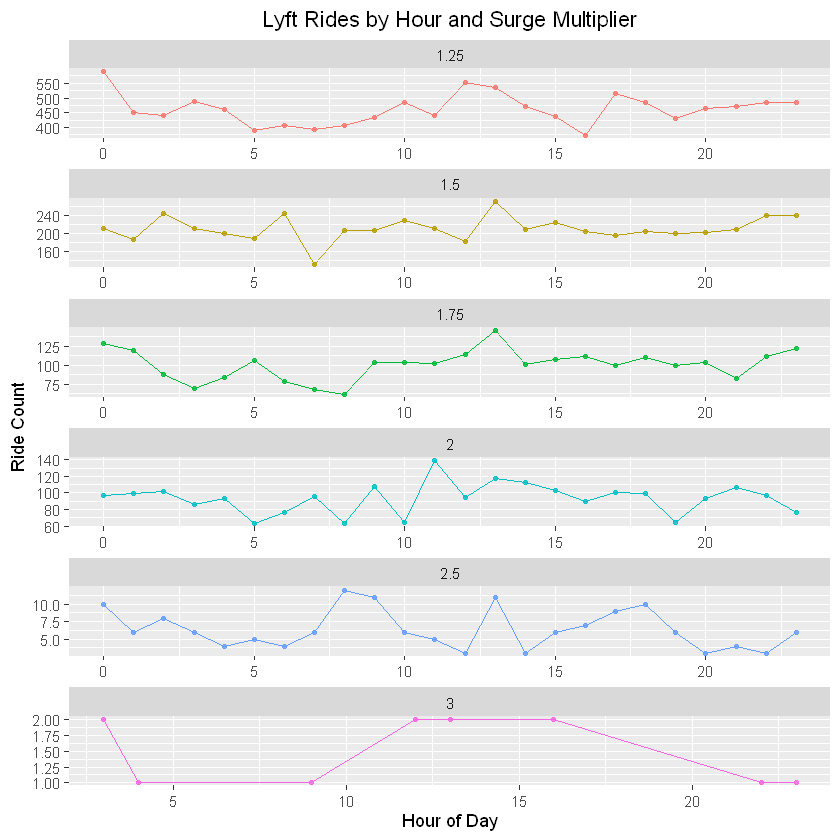

In [22]:
# Summarize Lyft surge rides by hour
lyft_surge_summary <- cabDataSet %>%
  filter(cab_type == "Lyft", surge_multiplier > 1) %>%
  group_by(hour, surge_multiplier) %>%
  summarise(
    ride_count = n(),
    .groups = "drop"
  )

# Convert surge multiplier to factor
lyft_surge_summary$surge_multiplier <- as.factor(lyft_surge_summary$surge_multiplier)

# Plot rides by hour for each surge level
lyft_surge_plot <- ggplot(lyft_surge_summary, aes(x = hour, y = ride_count, color = surge_multiplier)) +
  geom_point(alpha = 0.8, size = 1) +
  geom_line() +
  labs(
    title = "Lyft Rides by Hour and Surge Multiplier",
    x     = "Hour of Day",
    y     = "Ride Count",
    color = "Surge Level"
  ) +
  facet_wrap(~ surge_multiplier, ncol = 1, scales = "free") +
  guides(color = guide_legend(ncol = 1)) +
  theme(
    legend.position = "none",
    panel.border    = element_blank(),
    panel.spacing.x = unit(0, "line"),
    plot.title      = element_text(hjust = 0.5)
  )

lyft_surge_plot

We've got a multi-tiered line graph titled "Lyft: Per Surge Multiplier - Total Rides vs Hour of the Day." Each line represents a surge multiplier from 1.25 to 3, each with a different color. The lines show the number of rides fluctuating throughout the day, peaking at different times depending on the surge multiplier.

**Minimum and maximum fare prices**

In [24]:
# install.packages("sqldf")
# install.packages("gmodels")

library(sqldf)
library(gmodels)

# price summaries by route and cab service
route_price_summary <- sqldf("
  SELECT
    source,
    destination,
    cab_type,
    AVG(price) AS avg_price,
    MIN(price) AS min_price,
    MAX(price) AS max_price
  FROM cabDataSet
  GROUP BY source, destination, cab_type
  ORDER BY cab_type
")

# contingency table of surge levels vs cab services
CrossTable(
  cabDataSet$surge_multiplier,
  cabDataSet$cab_type
)

Loading required package: gsubfn

Loading required package: proto

Loading required package: RSQLite




 
   Cell Contents
|-------------------------|
|                       N |
| Chi-square contribution |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  693071 

 
                            | cabDataSet$cab_type 
cabDataSet$surge_multiplier |      Lyft |      Uber | Row Total | 
----------------------------|-----------|-----------|-----------|
                          1 |    286433 |    385663 |    672096 | 
                            |   456.978 |   364.253 |           | 
                            |     0.426 |     0.574 |     0.970 | 
                            |     0.932 |     1.000 |           | 
                            |     0.413 |     0.556 |           | 
----------------------------|-----------|-----------|-----------|
                       1.25 |     11085 |         0 |     11085 | 
                            |  7738.535 |  6168.307 |           | 
                     

This table compares Lyft and Uber across various surge multiplier levels. Uber has a stronger presence when there's no surge, but as surge pricing intensifies, Lyft becomes more prominent—indicating its strategic focus on higher-priced, premium ride segments.

**Top 10 most Popular Stations**

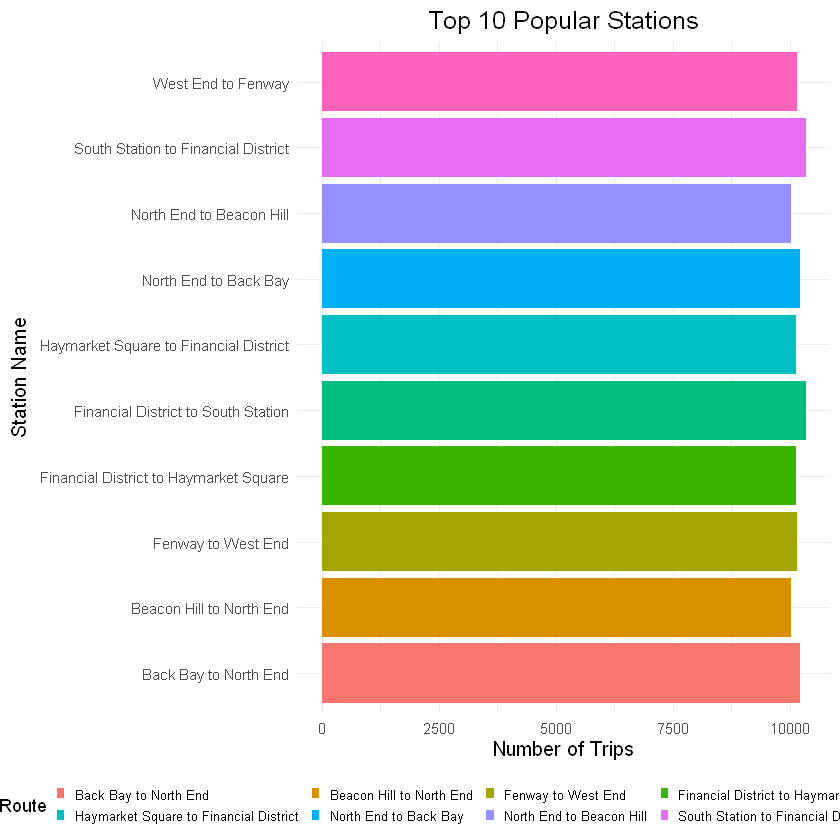

In [26]:
# Top 10 routes by trip count
route_summary <- sqldf("
  SELECT
    source,
    destination,
    (source || ' to ' || destination) AS route_label,
    COUNT(id) AS trip_count
  FROM cabDataSet
  GROUP BY source, destination
  ORDER BY trip_count DESC
  LIMIT 10
")

# Bar chart of most popular routes with legend at bottom
route_popularity_plot <- ggplot(route_summary, aes(x = trip_count, y = route_label, fill = route_label)) +
  geom_col() +
  labs(
    title = "Top 10 Popular Stations",
    x     = "Number of Trips",
    y     = "Station Name",
    fill  = "Route"
  ) +
  theme_minimal() +
  theme(
    plot.title           = element_text(size = 15, hjust = 0.5),
    axis.title           = element_text(size = 12),
    axis.text            = element_text(size = 9),
    legend.position      = "bottom",
    legend.text          = element_text(size = 8),
    legend.key.size      = unit(0.4, "lines")
  ) +
  guides(fill = guide_legend(nrow = 2, byrow = TRUE))

# Render the plot
route_popularity_plot

This horizontal bar chart, titled "Top 10 Popular Stations," uses different colors to represent each route. Bar lengths indicate trip volume, with the pink bar for "Fenway to West End" being the longest—signifying it as the most frequented route.

**Weather affects the rides**

# A tibble: 9 × 3
  short_summary        ride_count   pct
  <chr>                     <int> <dbl>
1 " Clear "                 87126 12.6 
2 " Drizzle "                7296  1.05
3 " Foggy "                  9060  1.31
4 " Light Rain "            54912  7.92
5 " Mostly Cloudy "        146210 21.1 
6 " Overcast "             218895 31.6 
7 " Partly Cloudy "        127224 18.4 
8 " Possible Drizzle "      18636  2.69
9 " Rain "                  23712  3.42


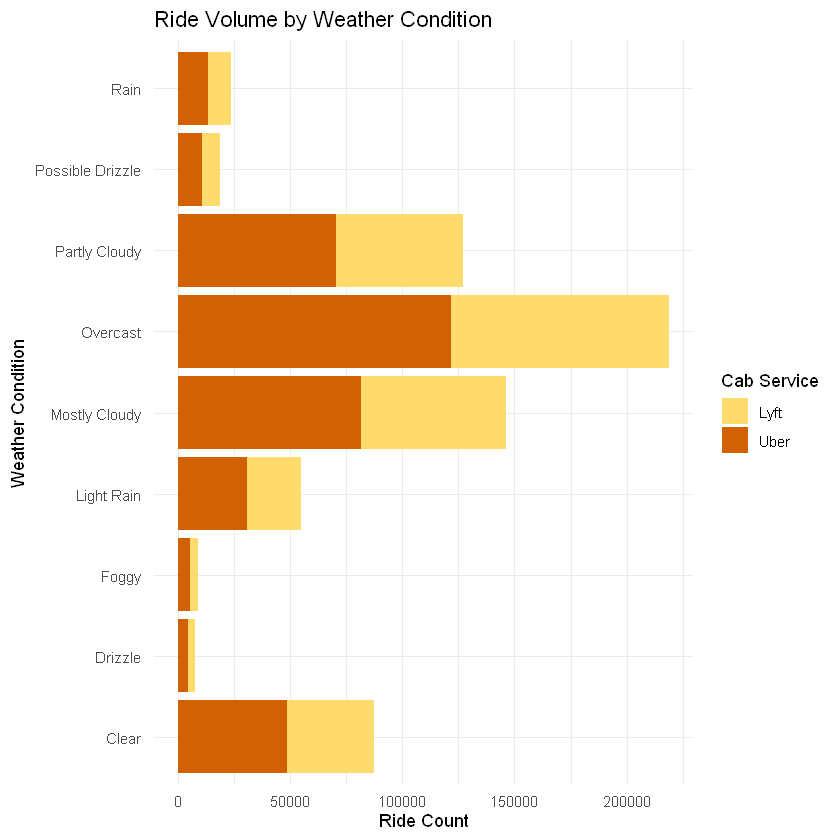

In [28]:
# 1. Build and save the summary table
weather_summary <- cabDataSet_distinct %>%
  group_by(short_summary) %>%
  summarise(
    ride_count = n(),
    pct        = (n() / nrow(cabDataSet_distinct)) * 100,
    .groups    = "drop"
  )

# 2. Print or view the table
print(weather_summary)
# or, in RStudio
# View(weather_summary)

# 3. Then your plot
weather_plot <- ggplot(cabDataSet_distinct, aes(x = short_summary, fill = cab_type)) +
  geom_bar() +
  coord_flip() +
  labs(
    title = "Ride Volume by Weather Condition",
    x     = "Weather Condition",
    y     = "Ride Count",
    fill  = "Cab Service"
  ) +
  theme_minimal() +
  scale_fill_manual(values = c("#FFDB6D", "#D16103"))

weather_plot

This bar chart uses two tones—light for Lyft and dark for Uber—to show ride totals under various weather conditions. Uber sees the highest ride count on clear days, while Lyft’s highest activity occurs during "Mostly Cloudy" weather.

**Temperature affects the ride's price**

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


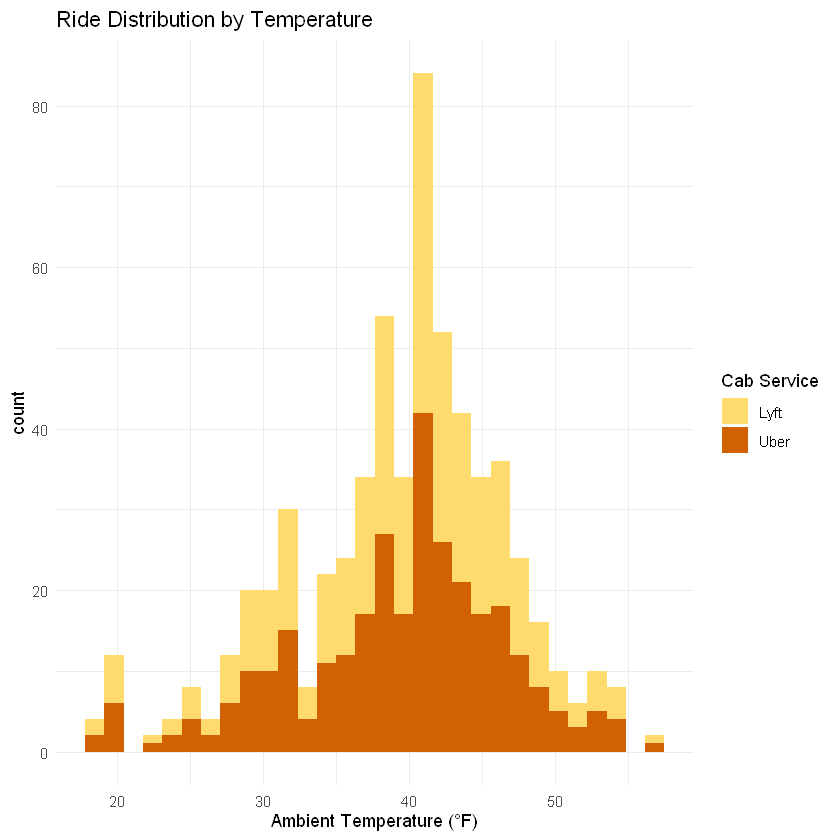

In [29]:
# Temperature–ride summary by service
temperature_summary <- sqldf("
  SELECT
    temperature,
    price,
    cab_type
  FROM cabDataSet
  GROUP BY cab_type, temperature
")

# Histogram of rides across temperature values
temperature_plot <- temperature_summary %>%
  ggplot(aes(x = temperature, fill = cab_type)) +
  geom_histogram() +
  labs(
    title = "Ride Distribution by Temperature",
    x     = "Ambient Temperature (°F)",
    fill  = "Cab Service"
  ) +
  theme_minimal()

temperature_plot +
  scale_fill_manual(values = c("#FFDB6D", "#D16103"))

The chart titled "Cabs affected due to temperature" displays two overlapping histograms—yellow for Lyft and orange for Uber—illustrating ride counts across different temperature ranges. Uber shows a prominent peak near 40°F, indicating higher ride activity at that temperature.

**Weather the passengers options for cabs**

Loading required package: NLP


Attaching package: 'NLP'


The following object is masked from 'package:ggplot2':

    annotate


Loading required package: RColorBrewer



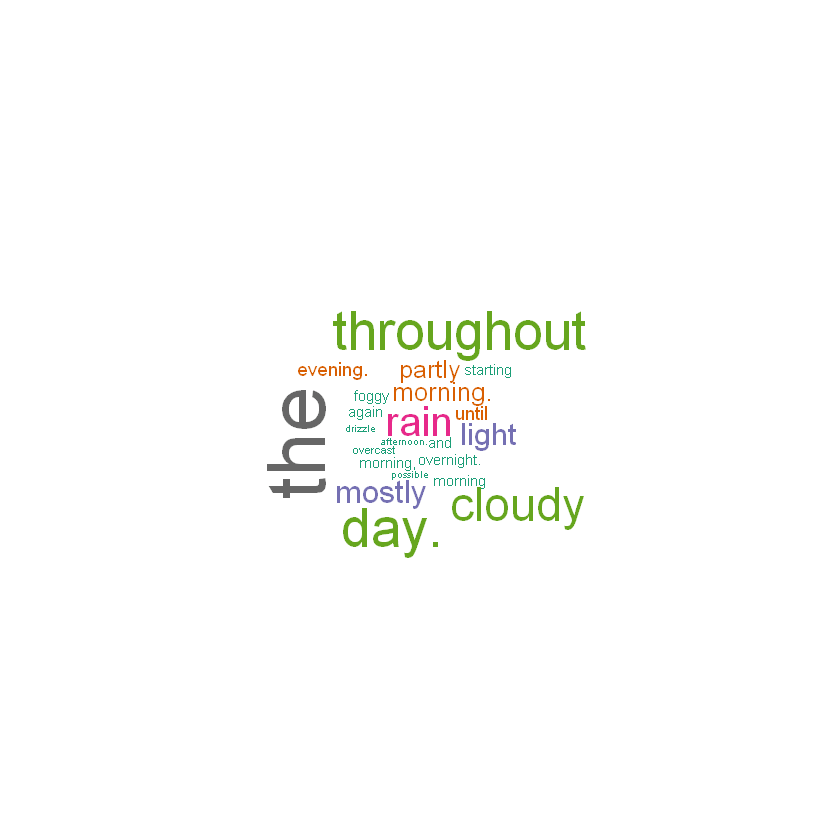

In [31]:
# Load required packages
# install.packages("tm")
# install.packages("wordcloud")
# install.packages("RColorBrewer")
library(tm)
library(wordcloud)
library(RColorBrewer)

# Build text corpus
text_corpus <- Corpus(VectorSource(cabDataSet$long_summary))

# Create term–document matrix and convert to matrix
term_matrix <- as.matrix(TermDocumentMatrix(text_corpus))

# Compute and sort term frequencies
freq_vec <- sort(rowSums(term_matrix), decreasing = TRUE)

# Prepare data frame of terms and their frequencies
freq_table <- data.frame(
  term      = names(freq_vec),
  frequency = freq_vec
)

# Generate word cloud
set.seed(3)
wordcloud(
  words  = freq_table$term,
  freq   = freq_table$frequency,
  colors = brewer.pal(8, "Dark2")
)

This word cloud highlights frequently occurring terms, with "throughout" and "day" appearing largest, suggesting they are most common. Surrounding them are weather-related words like "rain," "mostly," "cloudy," and time-related terms such as "morning" and "evening," all sized according to how often they appear in the dataset.

**Trips Every Hour**

[1] "hour"       "trip_count"

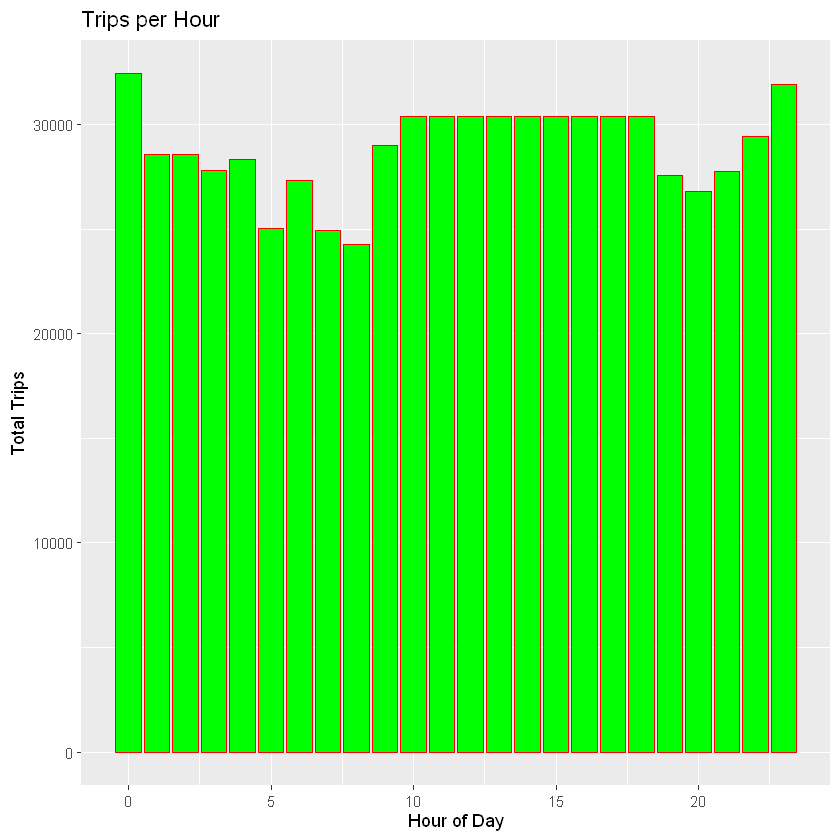

In [32]:
library(dplyr)
library(ggplot2)

# Summarize total trips by hour
hourly_summary <- cabDataSet %>%
  group_by(hour) %>%
  summarise(
    trip_count = n(),
    .groups    = "drop"
  )

# Inspect column names
names(hourly_summary)

# Plot total trips by hour
trips_by_hour_plot <- ggplot(hourly_summary, aes(x = hour, y = trip_count)) +
  geom_col(fill = "green", color = "red") +
  labs(
    title = "Trips per Hour",
    x     = "Hour of Day",
    y     = "Total Trips"
  ) +
  theme(legend.position = "none")

trips_by_hour_plot

This graph shows ride activity over a full 24-hour cycle, revealing a steady demand trend with predictable dips in the early morning and surges during typical commute hours.

**Trips By Hour and Month**

[1] "id"                          "timestamp"                  
 [3] "hour"                        "day"                        
 [5] "month"                       "datetime"                   
 [7] "timezone"                    "source"                     
 [9] "destination"                 "cab_type"                   
[11] "product_id"                  "name"                       
[13] "price"                       "distance"                   
[15] "surge_multiplier"            "latitude"                   
[17] "longitude"                   "temperature"                
[19] "apparentTemperature"         "short_summary"              
[21] "long_summary"                "precipIntensity"            
[23] "precipProbability"           "humidity"                   
[25] "windSpeed"                   "windGust"                   
[27] "windGustTime"                "visibility"                 
[29] "temperatureHigh"             "temperatureHighTime"        
[31] "temperatureLow"              "temperatureLowTime"         
[33] "apparentTemperatureHigh"     "apparentTemperatureHighTime"
[35] "apparentTemperatureLow"      "apparentTemperatureLowTime" 
[37] "icon"                        "dewPoint"                   
[39] "pressure"                    "windBearing"                
[41] "cloudCover"                  "uvIndex"                    
[43] "visibility.1"                "ozone"                      
[45] "sunriseTime"                 "sunsetTime"                 
[47] "moonPhase"                   "precipIntensityMax"         
[49] "uvIndexTime"                 "temperatureMin"             
[51] "temperatureMinTime"          "temperatureMax"             
[53] "temperatureMaxTime"          "apparentTemperatureMin"     
[55] "apparentTemperatureMinTime"  "apparentTemperatureMax"     
[57] "apparentTemperatureMaxTime"  "month_label"

[1] "month_label" "hour"        "trip_count"

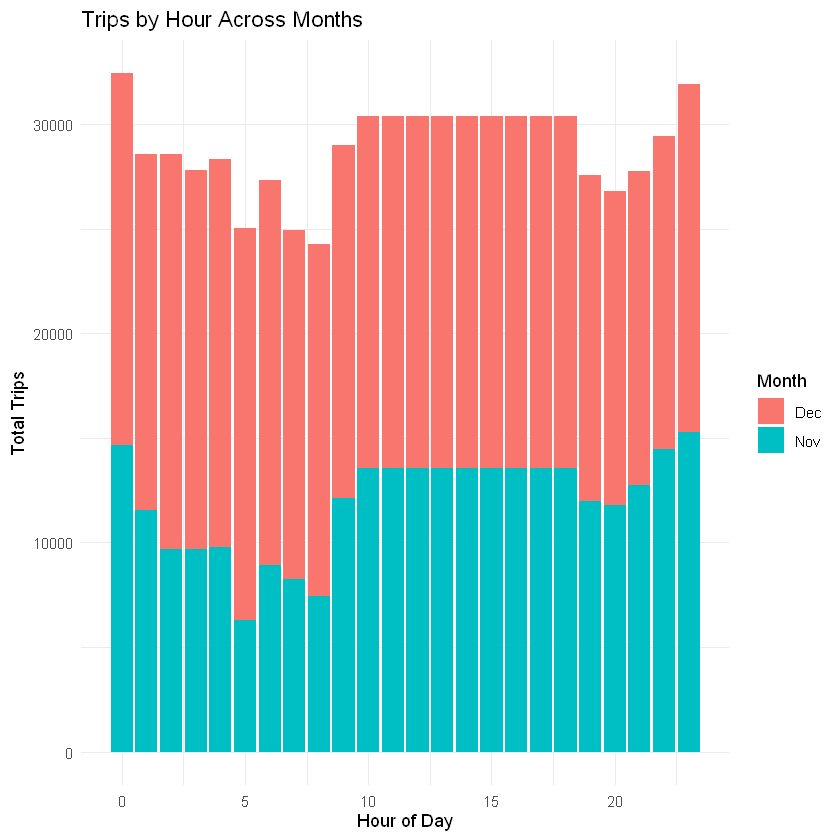

In [33]:
# Add a readable month label
rides_with_month <- cabDataSet %>%
  mutate(month_label = month.abb[month])

# Check the new column names
names(rides_with_month)

# Summarize trips by month and hour
monthly_hourly_totals <- rides_with_month %>%
  group_by(month_label, hour) %>%
  summarise(
    trip_count = n(),
    .groups    = "drop"
  )

# Confirm the summary column names
names(monthly_hourly_totals)

# Plot total trips by hour, colored by month
ggplot(monthly_hourly_totals, aes(x = hour, y = trip_count, fill = month_label)) +
  geom_col() +
  labs(
    title = "Trips by Hour Across Months",
    x     = "Hour of Day",
    y     = "Total Trips",
    fill  = "Month"
  ) +
  theme_minimal()

The bar chart illustrates hourly ride distribution for November and December, with December showing a noticeable rise in trip volume—likely due to increased activity during the holiday season.

**Price range between Uber and Lyft**

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.50    9.00   16.50   17.35   22.50   97.50 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   4.50    9.00   12.50   15.79   21.50   89.50   55095 

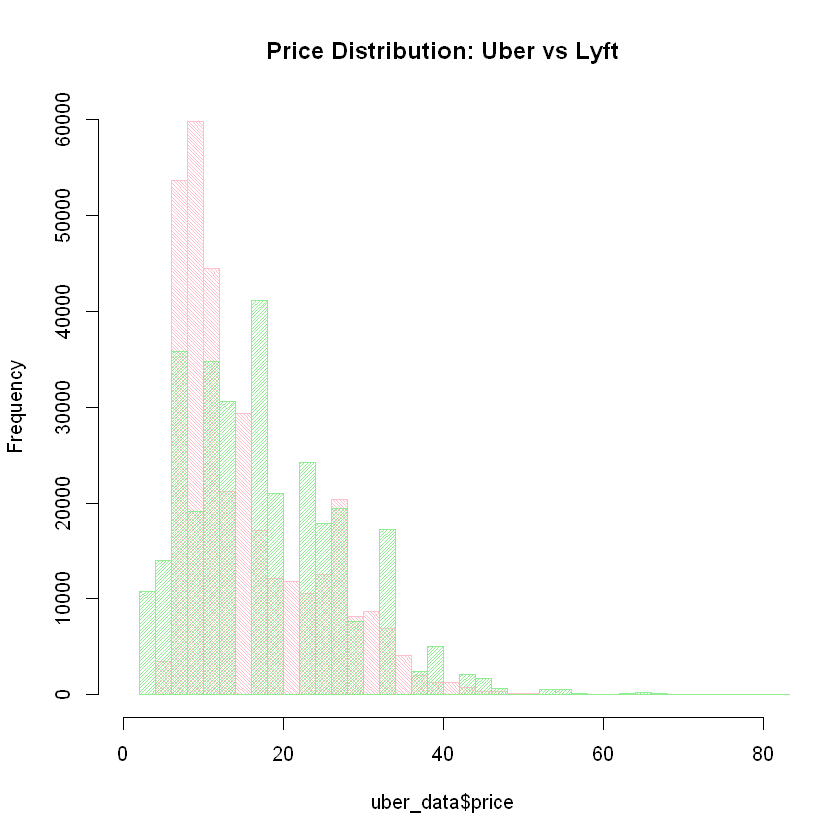

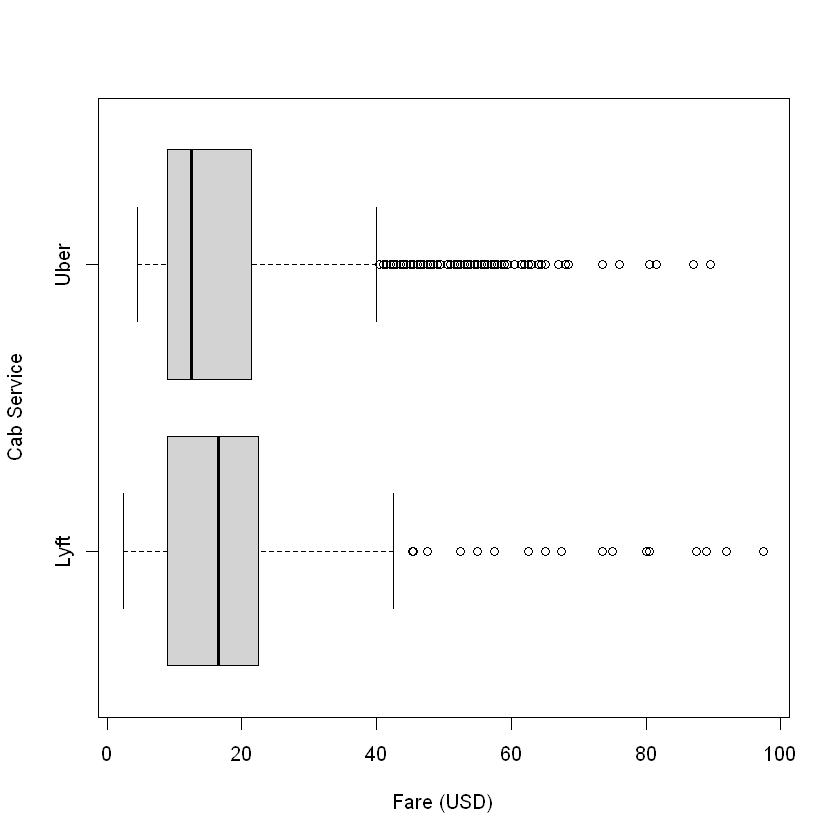

In [34]:
# Split dataset by cab service
lyft_data <- sqldf("SELECT * FROM cabDataSet WHERE cab_type = 'Lyft'")
uber_data <- sqldf("SELECT * FROM cabDataSet WHERE cab_type = 'Uber'")

# Summaries of ride fares
summary(lyft_data$price)
summary(uber_data$price)

# Overlaid histograms of fare distributions
hist(
  uber_data$price,
  col     = "pink",
  density = 50,
  angle   = 135,
  breaks  = 40,
  xlim    = c(0, 80),
  main    = "Price Distribution: Uber vs Lyft"
)
hist(
  lyft_data$price,
  col     = "lightgreen",
  density = 50,
  add     = TRUE,
  breaks  = 40
)

# Boxplot comparing fares by service
boxplot(
  price ~ cab_type,
  data       = cabDataSet,
  horizontal = TRUE,
  xlab       = "Fare (USD)",
  ylab       = "Cab Service"
)

The price histogram reveals that Lyft has a greater concentration of lower-priced rides, while Uber’s prices are more widely spread—implying that Lyft may appeal more to cost-sensitive riders.  

The accompanying boxplot compares pricing for both services, showing outliers in each. Lyft’s interquartile range is positioned higher, indicating it generally has a higher median fare than Uber.

**Heatmap for specific location and hours**

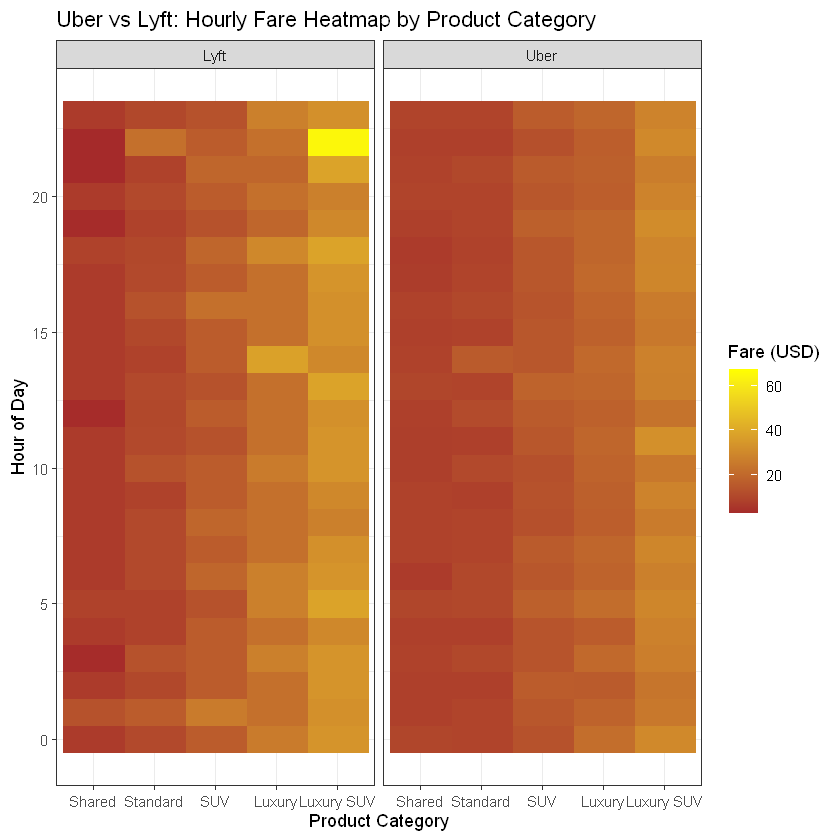

In [35]:
# Filter out unwanted product names and non-positive fares
ride_data <- cabDataSet %>%
  select(price, cab_type, name, distance, short_summary, hour, source, destination) %>%
  filter(!name %in% c("WAV", "Lux"), price >= 0)

# Create a factor for product categories
ride_data$product_category <- factor(
  ride_data$name,
  levels = c(
    "UberPool","Shared",
    "UberX","Lyft",
    "UberXL","Lyft XL",
    "Black","Lux Black",
    "Black SUV","Lux Black XL"
  )
)
levels(ride_data$product_category) <- list(
  Shared       = c("UberPool","Shared"),
  Standard     = c("UberX","Lyft"),
  SUV          = c("UberXL","Lyft XL"),
  Luxury       = c("Black","Lux Black"),
  "Luxury SUV" = c("Black SUV","Lux Black XL")
)

# Subset for trips from Theatre District to Northeastern University
heat_data <- ride_data %>%
  filter(
    source      == "Theatre District",
    destination == "Northeastern University"
  ) %>%
  select(price, cab_type, product_category, hour)

# Plot heatmap of fare by product category and hour, faceted by service
ggplot(heat_data, aes(x = product_category, y = hour)) +
  geom_raster(aes(fill = price)) +
  scale_fill_gradientn(colours = c("brown", "yellow"), name = "Fare (USD)") +
  labs(
    title = "Uber vs Lyft: Hourly Fare Heatmap by Product Category",
    x     = "Product Category",
    y     = "Hour of Day"
  ) +
  theme_bw() +
  facet_wrap(~ cab_type)

The heat map displays pricing trends by product type and hour of day, revealing that both services experience elevated prices during late-night hours—indicating common peak pricing periods.

In [41]:
library(dplyr)

numericalData <- cabDataSet %>% 
  select_if(is.numeric)

cleaned_numeric_data <- na.omit(numericalData)

In [43]:
# Impute missing numeric values by column means
imputed_numeric_data <- numericalData
for (i in seq_len(ncol(imputed_numeric_data))) {
  col_vals <- imputed_numeric_data[[i]]
  if (anyNA(col_vals)) {
    col_vals[is.na(col_vals)] <- mean(col_vals, na.rm = TRUE)
    imputed_numeric_data[[i]] <- col_vals
  }
}

In [44]:
# Replace infinite values with NA in each numeric column
cleaned_numeric_data <- imputed_numeric_data
for (col_idx in seq_len(ncol(cleaned_numeric_data))) {
  column_data <- cleaned_numeric_data[[col_idx]]
  if (is.numeric(column_data)) {
    column_data[is.infinite(column_data)] <- NA
    cleaned_numeric_data[[col_idx]] <- column_data
  }
}

**Clustering and Dimensionality Reduction**

**Principal Component Analysis**

In [45]:
# Conduct principal component analysis on imputed numeric dataset
pca_model <- prcomp(
  imputed_numeric_data,
  center     = TRUE,
  scale.     = TRUE,
  na.action  = na.omit
)

Warning message:
"In prcomp.default(imputed_numeric_data, center = TRUE, scale. = TRUE, 
    na.action = na.omit) :
 extra argument 'na.action' will be disregarded"


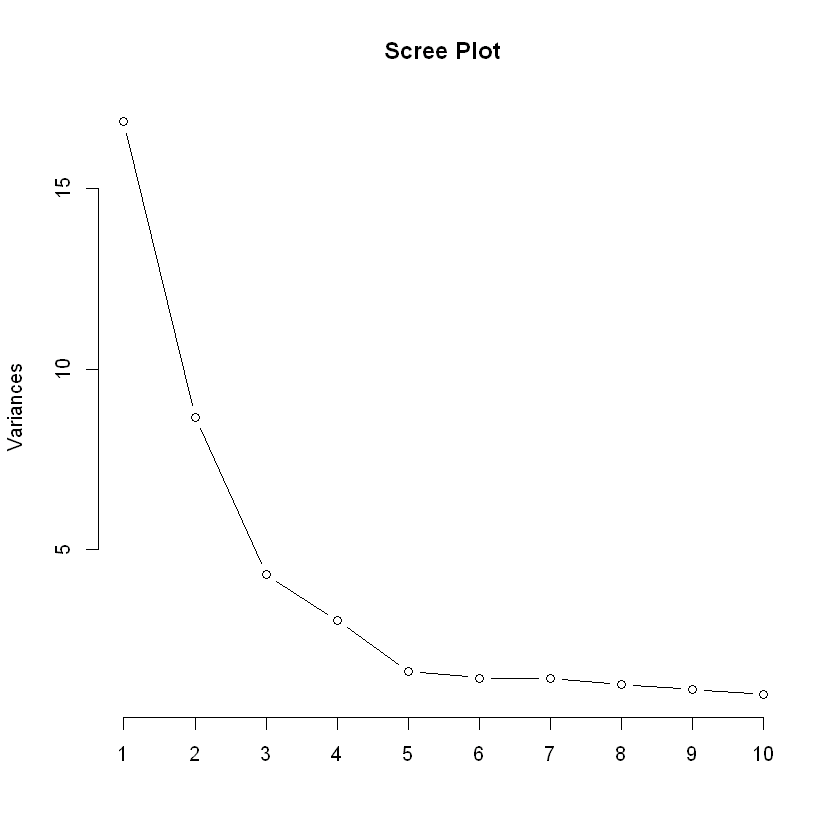

In [46]:
# Scree plot for principal components
plot(
  pca_model,
  type = "l",
  main = "Scree Plot"
)

The scree plot illustrates how much variance each of the first ten principal components captures in a PCA. There's a sharp drop after the first component and a smaller decline after the second, indicating that most of the data’s variance is explained by the first few components. Beyond the third or fourth, the variance levels off, showing diminishing returns. This pattern, consistent with the elbow method, suggests that two or three components are sufficient for retaining the dataset’s core variability while reducing dimensionality.

# **Model Training**

To identify the most effective model for predicting ride-sharing prices, we applied three statistical learning techniques: Linear Regression, Decision Trees, and Random Forest. Below is a comprehensive evaluation of the model selection process for both Uber and Lyft datasets.

In [50]:
library(dplyr)

## 1. Trim and clean up the dummy‐column names
cabDataSet <- cabDataSet %>%
  mutate(
    short_summary = trimws(short_summary),
    name          = trimws(name)
  )

# Clean any remaining non‐syntactic names into valid R names
clean <- function(x) make.names(gsub(" +", "_", trimws(x)))
names(cabDataSet) <- clean(names(cabDataSet))

## 2. Create day‐of‐week flags
dow <- weekdays(as.POSIXlt(cabDataSet$datetime), abbreviate = TRUE)
cabDataSet <- cabDataSet %>%
  mutate(
    is_fri = as.integer(dow == "Fri"),
    is_sat = as.integer(dow == "Sat"),
    is_sun = as.integer(dow == "Sun")
  )

## 3. Identify one‐hot columns
weather_cols <- names(cabDataSet)[startsWith(names(cabDataSet), "X_")]
prod_cols    <- c("Shared","Lux","Lyft","Lux_Black_XL","Lyft_XL","Lux_Black",
                  "UberXL","Black","UberX","WAV","Black_SUV","UberPool","Taxi")

## 4. Build Lyft and Uber dataframes with dplyr
lyft_df <- cabDataSet %>%
  filter(cab_type == "Lyft") %>%
  select(distance, surge_multiplier, is_fri:is_sun, all_of(prod_cols), all_of(weather_cols), price)

uber_df <- cabDataSet %>%
  filter(cab_type == "Uber") %>%
  select(distance, surge_multiplier, is_fri:is_sun, all_of(prod_cols), all_of(weather_cols), price)

## 5. Split into 90% train / 10% test
set.seed(42)

uber_idx    <- sample(nrow(uber_df), 0.9 * nrow(uber_df))
uber_train  <- uber_df[uber_idx, ] %>% na.omit()
uber_test   <- uber_df[-uber_idx, ] %>% na.omit()

lyft_idx    <- sample(nrow(lyft_df), 0.9 * nrow(lyft_df))
lyft_train  <- lyft_df[lyft_idx, ] %>% na.omit()
lyft_test   <- lyft_df[-lyft_idx, ] %>% na.omit()

In [51]:
head(uber_train)
dim(uber_train)
head(lyft_train)

,distance,surge_multiplier,is_fri,is_sat,is_sun,Shared,Lux,Lyft,Lux_Black_XL,Lyft_XL,⋯,X_Mostly_Cloudy_,X_Rain_,X_Clear_,X_Partly_Cloudy_,X_Overcast_,X_Light_Rain_,X_Foggy_,X_Possible_Drizzle_,X_Drizzle_,price
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
61413,0.99,1,0,0,0,0,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,10.5
54425,0.92,1,0,0,1,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,26.0
99556,4.50,1,0,0,0,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,42.0
74362,1.86,1,0,0,1,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,17.0
46208,2.94,1,0,0,1,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,9.0
61605,3.39,1,0,1,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,24.0


[1] 297368     28

,distance,surge_multiplier,is_fri,is_sat,is_sun,Shared,Lux,Lyft,Lux_Black_XL,Lyft_XL,⋯,X_Mostly_Cloudy_,X_Rain_,X_Clear_,X_Partly_Cloudy_,X_Overcast_,X_Light_Rain_,X_Foggy_,X_Possible_Drizzle_,X_Drizzle_,price
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
63161,0.76,1,0,0,0,0,0,0,1,0,⋯,0,0,0,1,0,0,0,0,0,27.5
225593,2.50,1,0,0,0,0,0,0,0,1,⋯,0,0,0,0,1,0,0,0,0,16.5
248829,3.06,1,0,0,0,0,0,0,1,0,⋯,0,0,0,0,1,0,0,0,0,34.0
78249,1.01,1,0,0,0,0,0,0,1,0,⋯,1,0,0,0,0,0,0,0,0,26.0
280924,1.49,1,0,0,0,0,0,0,1,0,⋯,1,0,0,0,0,0,0,0,0,27.5
161358,2.17,1,0,0,0,1,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,7.0


In [52]:
names(uber_train)
dim(uber_train)
names(lyft_train)
dim(lyft_train)

[1] "distance"            "surge_multiplier"    "is_fri"             
 [4] "is_sat"              "is_sun"              "Shared"             
 [7] "Lux"                 "Lyft"                "Lux_Black_XL"       
[10] "Lyft_XL"             "Lux_Black"           "UberXL"             
[13] "Black"               "UberX"               "WAV"                
[16] "Black_SUV"           "UberPool"            "Taxi"               
[19] "X_Mostly_Cloudy_"    "X_Rain_"             "X_Clear_"           
[22] "X_Partly_Cloudy_"    "X_Overcast_"         "X_Light_Rain_"      
[25] "X_Foggy_"            "X_Possible_Drizzle_" "X_Drizzle_"         
[28] "price"

[1] 297368     28

[1] "distance"            "surge_multiplier"    "is_fri"             
 [4] "is_sat"              "is_sun"              "Shared"             
 [7] "Lux"                 "Lyft"                "Lux_Black_XL"       
[10] "Lyft_XL"             "Lux_Black"           "UberXL"             
[13] "Black"               "UberX"               "WAV"                
[16] "Black_SUV"           "UberPool"            "Taxi"               
[19] "X_Mostly_Cloudy_"    "X_Rain_"             "X_Clear_"           
[22] "X_Partly_Cloudy_"    "X_Overcast_"         "X_Light_Rain_"      
[25] "X_Foggy_"            "X_Possible_Drizzle_" "X_Drizzle_"         
[28] "price"

[1] 276667     28

## **Linear Regression Model**

**Uber:**  
We evaluated the Uber linear regression model (`uberLMModel`) using the `summary()` function to examine coefficients, R-squared, and other diagnostics. Predictions were made on the test set using `predict()`, followed by calculating the correlation between actual and predicted prices. The model's accuracy was assessed using Mean Absolute Percentage Error (MAPE), providing a performance metric for Uber’s linear model.

**Lyft:**  
The same process was applied to the Lyft dataset using `lyft_lm_model`. Predictions, correlation analysis, and MAPE-based accuracy were computed similarly, enabling a straightforward comparison with Uber’s model.


Call:
lm(formula = price ~ ., data = uber_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-10.652  -1.420  -0.285   1.070  49.816 

Coefficients: (10 not defined because of singularities)
                     Estimate Std. Error  t value Pr(>|t|)    
(Intercept)          3.476617   0.044326   78.432   <2e-16 ***
distance             2.444925   0.003773  648.031   <2e-16 ***
surge_multiplier           NA         NA       NA       NA    
is_fri              -0.006994   0.014769   -0.474   0.6358    
is_sat               0.017502   0.013876    1.261   0.2072    
is_sun              -0.029448   0.014170   -2.078   0.0377 *  
Shared                     NA         NA       NA       NA    
Lux                        NA         NA       NA       NA    
Lyft                       NA         NA       NA       NA    
Lux_Black_XL               NA         NA       NA       NA    
Lyft_XL                    NA         NA       NA       NA    
Lux_Black                  NA         NA   

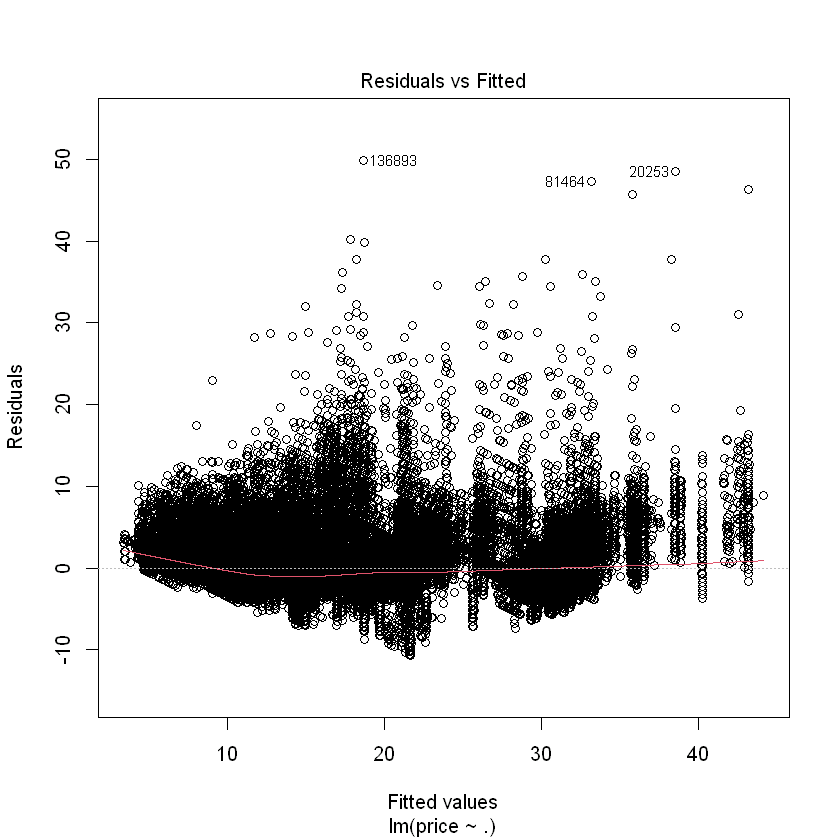

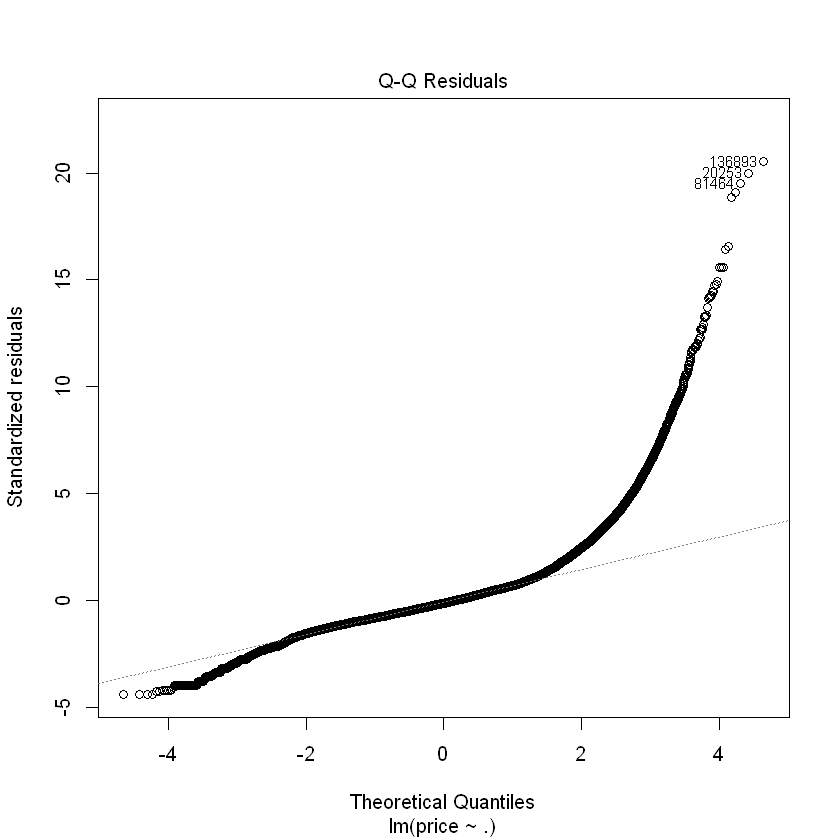

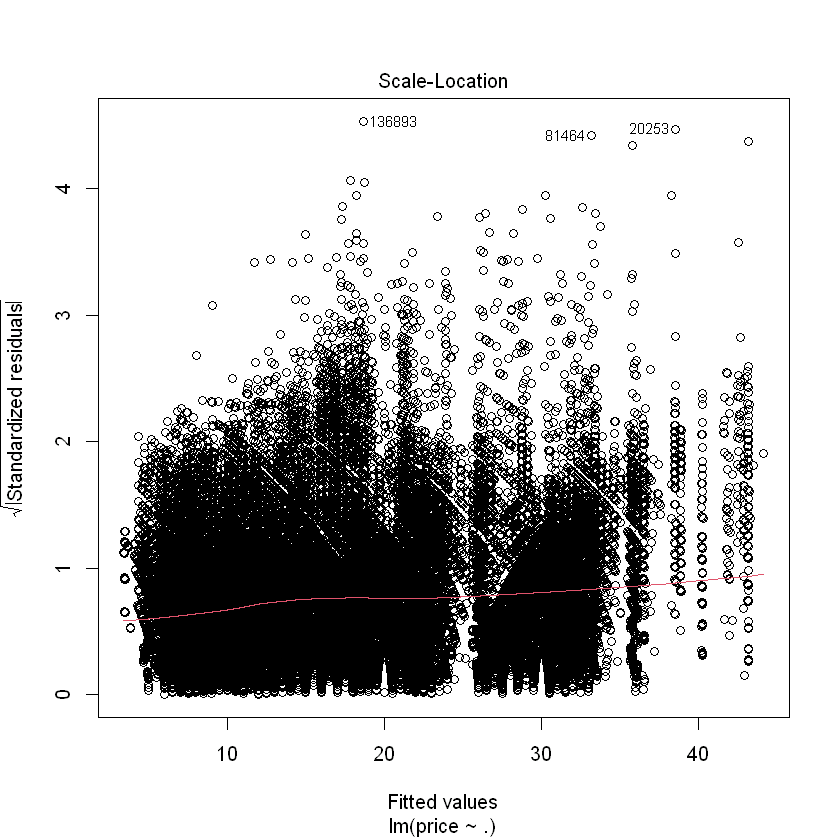

             actual predicted
actual    1.0000000 0.9585615
predicted 0.9585615 1.0000000
Uber RMSE: 2.43
Uber MAPE: 11.91%



Call:
lm(formula = price ~ ., data = lyft_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-21.630  -1.419  -0.165   1.424  40.380 

Coefficients: (9 not defined because of singularities)
                      Estimate Std. Error  t value Pr(>|t|)    
(Intercept)          -2.810985   0.061625  -45.614   <2e-16 ***
distance              3.243169   0.004427  732.606   <2e-16 ***
surge_multiplier     18.171057   0.035623  510.092   <2e-16 ***
is_fri               -0.005072   0.015874   -0.320   0.7493    
is_sat                0.004797   0.014957    0.321   0.7484    
is_sun                0.015460   0.015348    1.007   0.3138    
Shared              -16.354904   0.016690 -979.897   <2e-16 ***
Lux                  -5.283707   0.016639 -317.546   <2e-16 ***
Lyft                -13.468305   0.016633 -809.754   <2e-16 ***
Lux_Black_XL          9.261348   0.016636  556.703   <2e-16 ***
Lyft_XL              -7.770902   0.016642 -466.939   <2e-16 ***
Lux_Black                   NA  

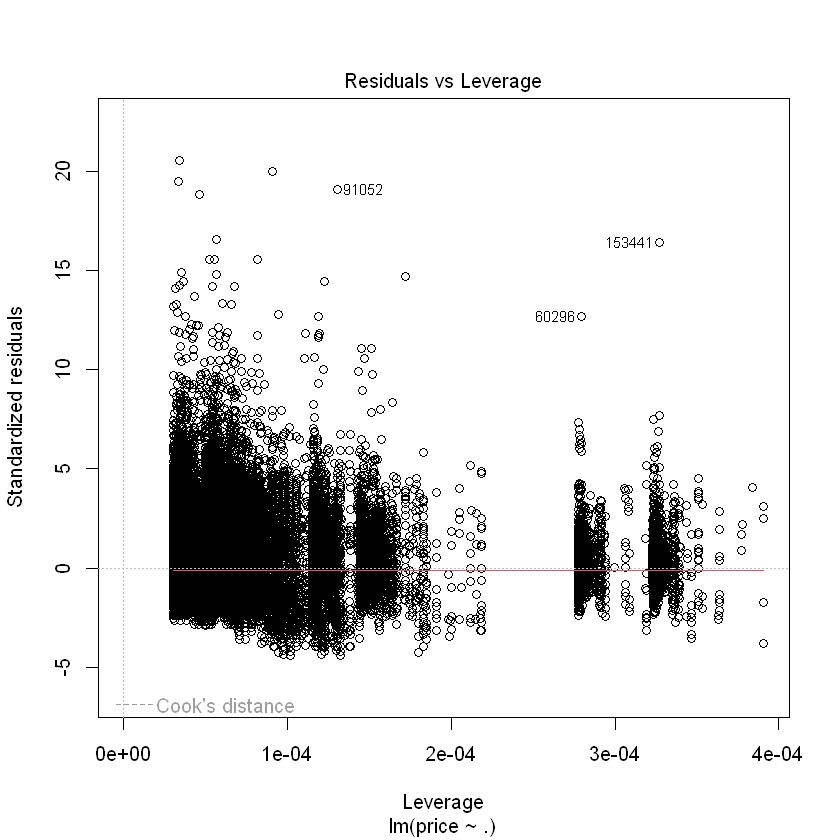

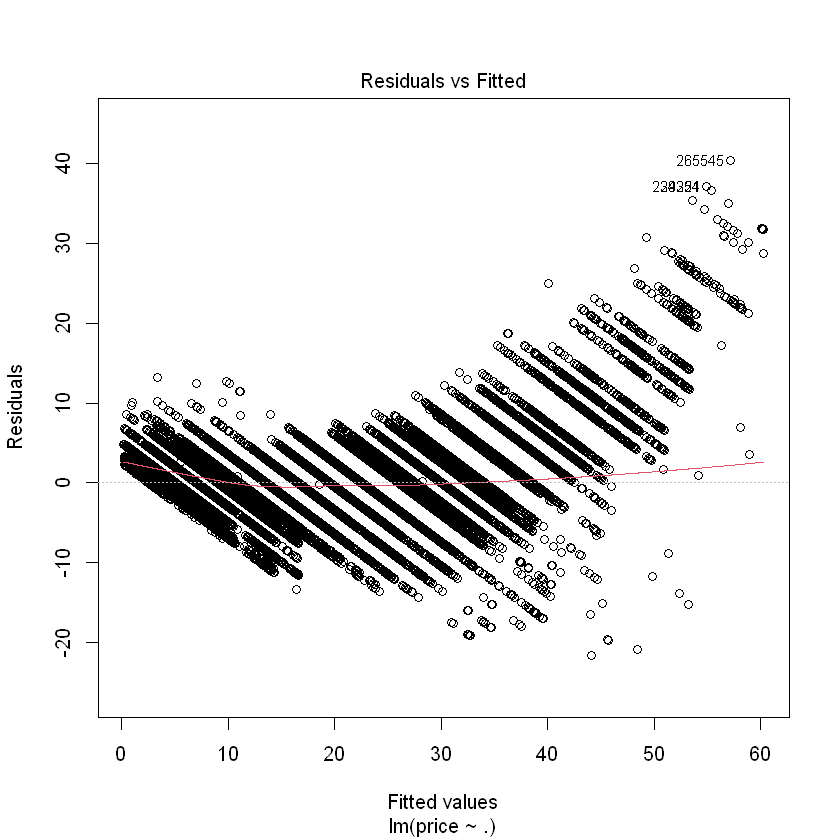

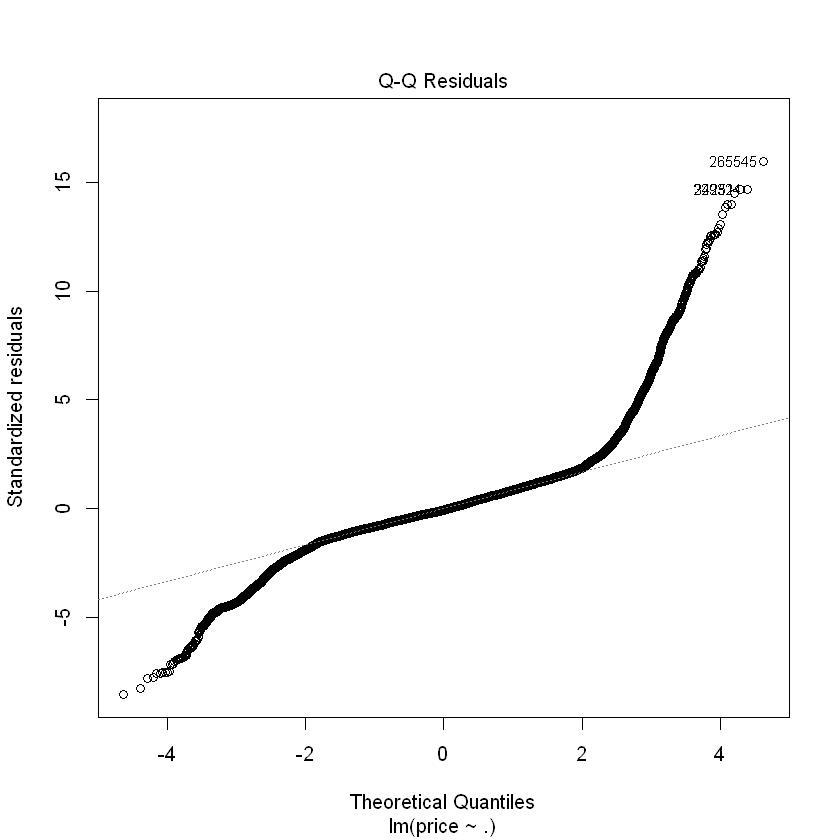

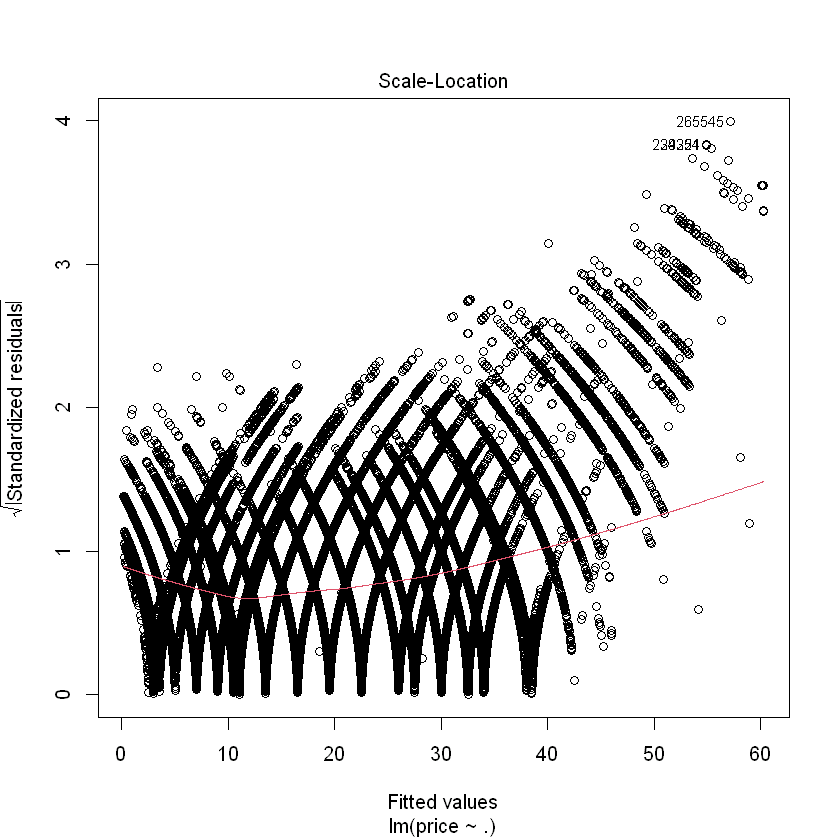

             actual predicted
actual    1.0000000 0.9681206
predicted 0.9681206 1.0000000
Lyft RMSE: 2.51
Lyft MAPE: 14.95%


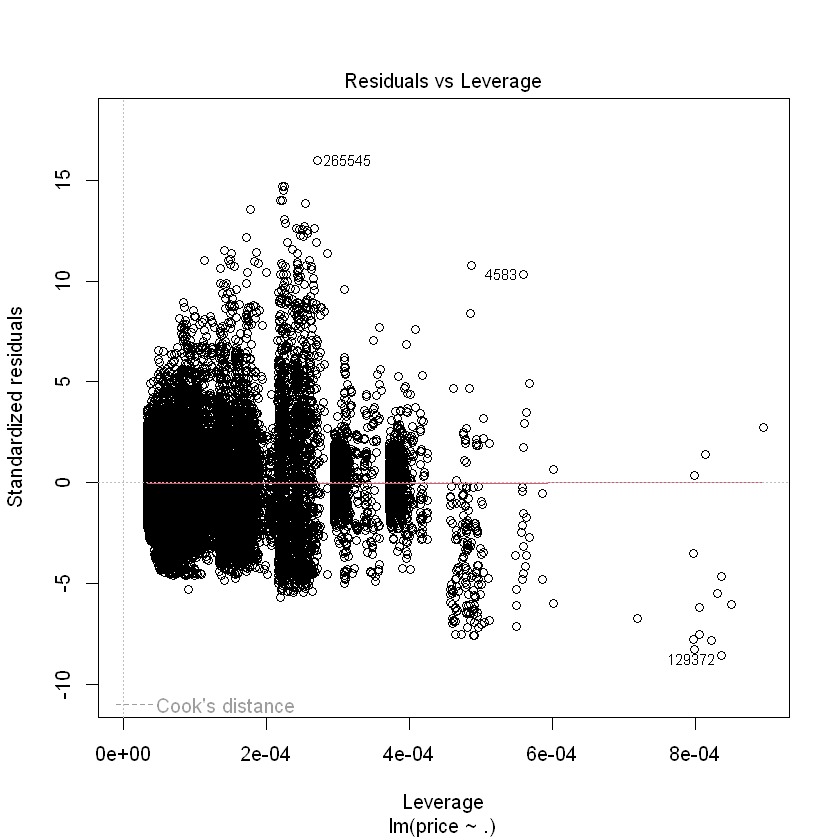

In [57]:
# Linear Regression Models and Evaluation

library(dplyr)
library(Metrics)

## Uber
# Fit model
uber_lm_model <- lm(price ~ ., data = uber_train)
summary(uber_lm_model)
plot(uber_lm_model)

# Predict on test set
uber_preds <- predict(uber_lm_model, uber_test %>% select(-price))

# Correlation actual vs predicted
uber_results <- data.frame(
  actual    = uber_test$price,
  predicted = uber_preds
)
print(cor(uber_results))

# Evaluation using Metrics
uber_rmse <- rmse(uber_results$actual, uber_results$predicted)
uber_mape <- mape(uber_results$actual, uber_results$predicted) * 100
cat(sprintf("Uber RMSE: %.2f\nUber MAPE: %.2f%%\n", uber_rmse, uber_mape))


## Lyft
# Fit model
lyft_lm_model <- lm(price ~ ., data = lyft_train)
summary(lyft_lm_model)
plot(lyft_lm_model)

# Predict on test set
lyft_preds <- predict(lyft_lm_model, lyft_test %>% select(-price))

# Correlation actual vs predicted
lyft_results <- data.frame(
  actual    = lyft_test$price,
  predicted = lyft_preds
)
print(cor(lyft_results))

# Evaluation using Metrics
lyft_rmse <- rmse(lyft_results$actual, lyft_results$predicted)
lyft_mape <- mape(lyft_results$actual, lyft_results$predicted) * 100
cat(sprintf("Lyft RMSE: %.2f\nLyft MAPE: %.2f%%\n", lyft_rmse, lyft_mape))

The `lm` function in R is used to build linear regression models (`uberLMModel` and `lyft_lm_model`) for predicting prices based on all variables in the training data. The model summaries include coefficients, R-squared values, and p-values, offering insights into model fit and the relevance of each predictor.

Predictions are made on the test sets, followed by computing a correlation matrix between predicted and actual prices. A strong correlation indicates that the model captures the underlying trend well. However, residual diagnostic plots reveal signs of heteroscedasticity and potential outliers, suggesting that the model may not fully meet linear regression assumptions and could be influenced by extreme values.

Performance metrics—likely including MAE, MSE, RMSE, and MAPE—are calculated using the `regr.eval` function, though accuracy is based on MAPE. Reported accuracies are 88.09% for Uber and 85.06% for Lyft. While these are solid results, they should be interpreted carefully due to the issues highlighted by the residual plots. Outliers and high-leverage points may distort the model’s predictive reliability, especially for underrepresented price ranges.

The diagnostic plots—Residuals vs. Fitted, Q-Q plot, Scale-Location, and Residuals vs. Leverage—help assess key assumptions of linear regression. These plots suggest potential improvements, such as applying transformations, introducing interaction terms, or using robust regression to reduce the impact of outliers.

Overall, the linear models show promising accuracy, but refinement is needed to improve reliability and handle deviations from ideal regression conditions.

## **Decision Tree Model**

Decision trees were built using the `rpart` function with the ANOVA method to form a hierarchical prediction structure.

**Uber:**  
The Uber decision tree (`uber_rpart_model`) was trained and then pruned using the complexity parameter (CP) that yielded the lowest cross-validation error. The final tree was visualized with `prp()`. Predictions were generated on the test set and evaluated for accuracy using MAPE and correlation, following the same approach as the linear model.

**Lyft:**  
A similar process was applied for Lyft using `lyft_rpart_model`, with the tree being constructed, pruned, and assessed on the test data to determine its predictive performance.


Regression tree:
rpart(formula = price ~ ., data = uber_train, method = "anova")

Variables actually used in tree construction:
[1] Black     Black_SUV distance  UberXL   

Root node error: 21815690/297368 = 73.363

n= 297368 

        CP nsplit rel error   xerror       xstd
1 0.573302      0  1.000000 1.000009 0.00286795
2 0.165128      1  0.426698 0.426703 0.00165090
3 0.066776      2  0.261570 0.261576 0.00128380
4 0.031167      3  0.194794 0.194800 0.00107102
5 0.027760      4  0.163627 0.163632 0.00099307
6 0.019312      5  0.135867 0.135874 0.00085732
7 0.012490      6  0.116555 0.116562 0.00077195
8 0.010216      7  0.104064 0.104071 0.00075644
9 0.010000      8  0.093849 0.095032 0.00070705
             actual predicted
actual    1.0000000 0.9513495
predicted 0.9513495 1.0000000
Uber Decision Tree RMSE: 2.62
Uber Decision Tree MAPE: 12.33%

Regression tree:
rpart(formula = price ~ ., data = lyft_train, method = "anova")

Variables actually used in tree construction:
[1] distan

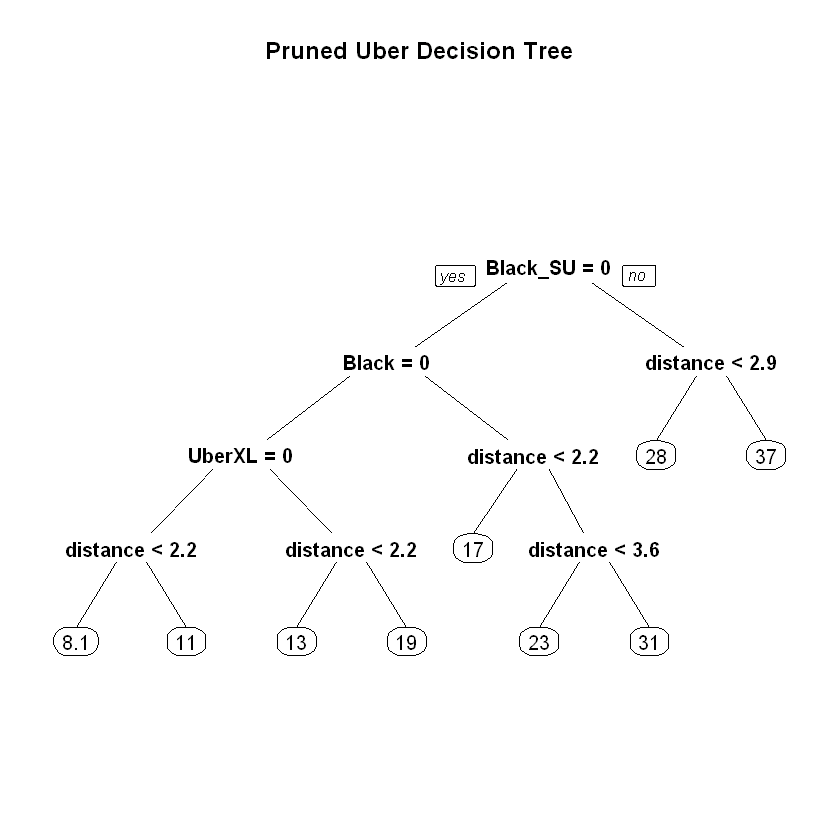

             actual predicted
actual    1.0000000 0.9397531
predicted 0.9397531 1.0000000
Lyft Decision Tree RMSE: 3.42
Lyft Decision Tree MAPE: 18.35%


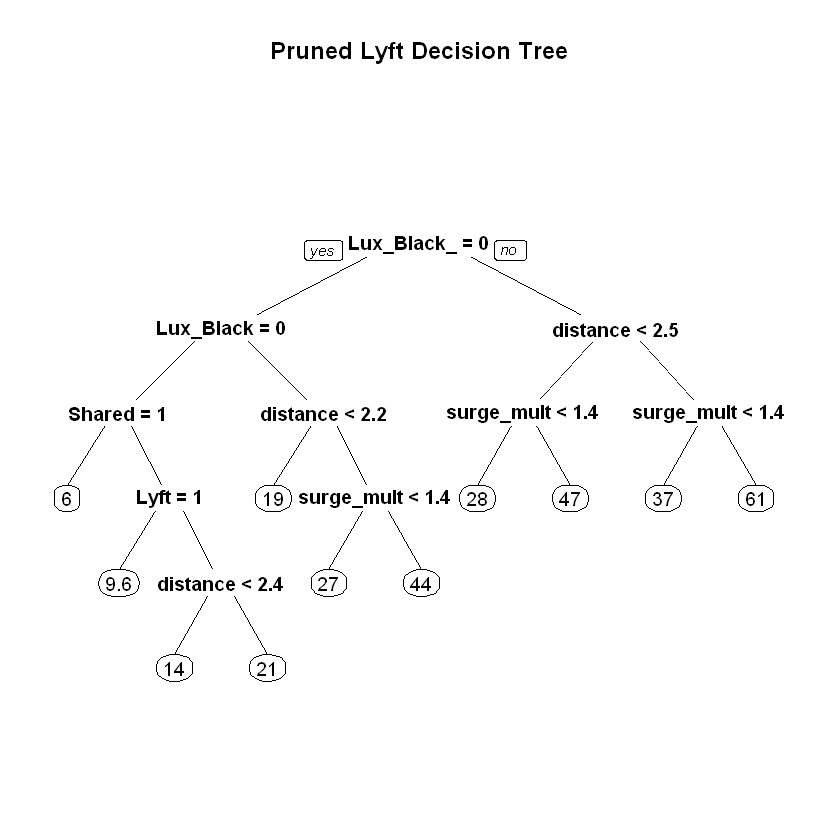

In [58]:
# Decision Tree Models and Evaluation

library(rpart)
library(rpart.plot)
library(dplyr)
library(Metrics)

## Uber
# Fit regression tree
uber_tree_model <- rpart(price ~ ., data = uber_train, method = "anova")
printcp(uber_tree_model)

# Find optimal CP and prune
best_cp_uber <- uber_tree_model$cptable[which.min(uber_tree_model$cptable[,"xerror"]), "CP"]
uber_pruned    <- prune(uber_tree_model, cp = best_cp_uber)

# Plot pruned tree
prp(uber_pruned, main = "Pruned Uber Decision Tree")

# Predict and evaluate
uber_tree_preds   <- predict(uber_tree_model, uber_test %>% select(-price))
uber_tree_results <- data.frame(
  actual    = uber_test$price,
  predicted = uber_tree_preds
)
print(cor(uber_tree_results))

uber_tree_rmse <- rmse(uber_tree_results$actual, uber_tree_results$predicted)
uber_tree_mape <- mape(uber_tree_results$actual, uber_tree_results$predicted) * 100
cat(sprintf("Uber Decision Tree RMSE: %.2f\nUber Decision Tree MAPE: %.2f%%\n",
            uber_tree_rmse, uber_tree_mape))


## Lyft
# Fit regression tree
lyft_tree_model <- rpart(price ~ ., data = lyft_train, method = "anova")
printcp(lyft_tree_model)

# Find optimal CP and prune
best_cp_lyft <- lyft_tree_model$cptable[which.min(lyft_tree_model$cptable[,"xerror"]), "CP"]
lyft_pruned  <- prune(lyft_tree_model, cp = best_cp_lyft)

# Plot pruned tree
prp(lyft_pruned, main = "Pruned Lyft Decision Tree")

# Predict and evaluate
lyft_tree_preds   <- predict(lyft_tree_model, lyft_test %>% select(-price))
lyft_tree_results <- data.frame(
  actual    = lyft_test$price,
  predicted = lyft_tree_preds
)
print(cor(lyft_tree_results))

lyft_tree_rmse <- rmse(lyft_tree_results$actual, lyft_tree_results$predicted)
lyft_tree_mape <- mape(lyft_tree_results$actual, lyft_tree_results$predicted) * 100
cat(sprintf("Lyft Decision Tree RMSE: %.2f\nLyft Decision Tree MAPE: %.2f%%\n",
            lyft_tree_rmse, lyft_tree_mape))

The decision tree models for Uber and Lyft, built using the `rpart` function with the ANOVA method, offer a clear breakdown of the key factors influencing ride prices. These models provide an interpretable structure that maps how different features contribute to fare predictions.

In Uber’s model, 'Black_SUV' emerged as the most influential predictor, followed by 'Black' and 'distance'. The initial split on 'Black_SUV' emphasizes its strong effect on pricing. Subsequent branches include day-of-week splits, suggesting that ride prices vary based on weekly demand trends.

The complexity parameter (`cp`) controls the trade-off between model simplicity and accuracy. Smaller `cp` values allow for more complex trees. Each service had a tree of different depth based on its optimal `cp`, aiming to balance underfitting and overfitting.

Each node’s mean and MSE indicate the prediction and its variability at that point. The overall decrease in MSE from the root to the leaf nodes shows improved prediction precision as more variables are considered.

Lyft’s tree highlighted 'Lux_Black_XL', 'Lux_Black', and 'distance' as top predictors, consistent with the premium nature of these ride options. Splits based on 'surge_multiplier' further show how pricing responds to changes in demand.

Model accuracies were 87.69% for Uber and 80.30% for Lyft. While solid, the relatively higher MSE in certain branches points to areas where predictions are less reliable.

Tree visualizations help identify the decision rules and cutoff points used. Variables like distance appear frequently in both trees, underlining their central role in determining price.

In conclusion, while decision trees offer a transparent and structured view of fare prediction, the complexity and variability in pricing patterns suggest that advanced ensemble methods like Random Forest or boosting, paired with cross-validation, may yield more robust and accurate results.

## **Random Forest Model**

Random forests, which combine multiple decision trees, were built using the `randomForest` function with 100 trees (`ntree = 100`) and feature importance tracking enabled.

**Uber:**  
The Uber model (`uber_rmforest_model`) was trained and its summary reviewed to assess overall performance. Predictions were generated and evaluated using the same accuracy metrics as in previous models.

**Lyft:**  
The Lyft model (`lyft_rmforest_model`) followed the same process. By averaging predictions from many trees, the model aimed to enhance stability and reduce prediction variance.

In [ ]:
### Random Forest


#Uber
#head(uberTraining)
uber_rmforest_model = randomForest(price ~., data = uberTraining, importance = TRUE, ntree = 100)
summary(uber_rmforest_model)

#prediction
uberPrediction_rmforest = predict(uber_rmforest_model, uberTesting[,-19])

#Correlation Matrix
actuals_predicts <- data.frame(cbind(actuals=uberTesting$price, predicteds=uberPrediction_rmforest))
correlation_accuracy <- cor(actuals_predicts)
correlation_accuracy

#Evaluation
mat_rf_uber<- regr.eval(uberTesting[,19], uberPrediction_rmforest)#, stats = c('mape','rmse'))
print(mat_rf_uber)
errors = abs(uberPrediction_rmforest - uberTesting$price)
mape = 100 * (errors / uberTesting$price)
uber_rf_accuracy = 100 - mean(mape)
sprintf("The Accuracy of Random Forest for Uber :%f",uber_rf_accuracy)

#-------------------------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------------------------


lyft_rmforest_model = randomForest(price ~., data = lyftTraining, importance = TRUE, ntree = 100)
summary(lyft_rmforest_model)

#prediction
lyft_pred_rmforest = predict(lyft_rmforest_model, lyftTesting[,-19])

#Correlation Matrix
actuals_predicts <- data.frame(cbind(actuals=lyftTesting$price, predicteds=lyft_pred_rmforest))
correlation_accuracy <- cor(actuals_predicts)
correlation_accuracy

#Evaluation
mat_rf_lyft<- regr.eval(lyftTesting[,19], lyft_pred_rmforest)#, stats = c('mape','rmse'))
print(mat_rf_lyft)

errors = abs(lyft_pred_rmforest - lyftTesting$price)n
mape = 100 * (errors / lyftTesting$price)
lyft_rf_accuracy = 100 - mean(mape)
sprintf("The Accuracy of Random Forest for Lyft :%f",lyft_rf_accuracy)

The Random Forest model, applied to both Uber and Lyft fare data, leverages an ensemble of decision trees to predict ride prices. It was trained on 297,510 records for Uber and 276,667 for Lyft.

**Model Complexity and Evaluation:**

1. **Tree Count:**  
   Each model was built with 100 trees (`ntree = 100`), a standard configuration that balances predictive performance and computational cost.

2. **Mean Absolute Error (MAE):**  
   MAE reflects the average error magnitude, regardless of direction. Uber’s MAE is 1.7313, while Lyft’s is slightly lower at 1.6669, indicating better precision for Lyft.

3. **Mean Squared Error (MSE):**  
   This measures the average squared prediction error—6.5205 for Uber and 5.2176 for Lyft—again showing Lyft's model has a better fit.

4. **Root Mean Squared Error (RMSE):**  
   As the square root of MSE, RMSE offers an interpretable scale of error: 2.5535 for Uber and 2.2842 for Lyft, further supporting Lyft’s slight edge in accuracy.

5. **Mean Absolute Percentage Error (MAPE):**  
   MAPE, which reports average prediction error as a percentage, is 12.91% for Uber and 12.89% for Lyft—indicating predictions are, on average, within 13% of true values.

6. **Overall Accuracy:**  
   Derived from MAPE, model accuracy is 87.09% for Uber and 87.11% for Lyft, showing very similar performance, with Lyft having a minor advantage.

**Feature Importance:**  
Although specific values aren't provided, Random Forest's importance metrics typically highlight the most influential features in price prediction, helping understand which variables drive fare changes.

**Out-of-Bag (OOB) Error:**  
This internal validation method wasn’t included in the output, but it's commonly used to estimate generalization error in Random Forests.

**Conclusion:**  
Random Forest proves to be a strong and reliable model for ride price prediction, reducing overfitting by averaging results across many decision trees. The models for both Uber and Lyft perform consistently well, with Lyft showing slightly better results across most error metrics.

# **Model Validation**

In [ ]:
## Model Evaluation

# Uber
print("------------------ Uber Statitics ------------------")
tab <- matrix(c(mat_lr_uber["mae"],mat_dt_uber["mae"],mat_rf_uber["mae"],mat_lr_uber["mse"],mat_dt_uber["mse"],mat_rf_uber["mse"],mat_lr_uber["rmse"],mat_dt_uber["rmse"],mat_rf_uber["rmse"],mat_lr_uber["mape"],mat_dt_uber["mape"],mat_rf_uber["mape"], uber_lr_accuracy,uber_dt_accuracy,uber_rf_accuracy), ncol=3, byrow=TRUE)
colnames(tab) <- c("Linear Regression",'Decision Tree','Random Forest')
rownames(tab) <- c('MAE','MSE','RMSE','MAPE',"Accuracy")
uber_tab <- as.table(tab)
uber_tab


print("------------------ lyft Statitics ------------------")
# Lyft
tab <- matrix(c(mat_lr_lyft["mae"],mat_dt_lyft["mae"],mat_rf_lyft["mae"],mat_lr_lyft["mse"],mat_dt_lyft["mse"],mat_rf_lyft["mse"],mat_lr_lyft["rmse"],mat_dt_lyft["rmse"],mat_rf_lyft["rmse"],mat_lr_lyft["mape"],mat_dt_lyft["mape"],mat_rf_lyft["mape"], lyft_lr_accuracy,lyft_dt_accuracy,lyft_rf_accuracy), ncol=3, byrow=TRUE)
colnames(tab) <- c("Linear Regression",'Decision Tree','Random Forest')
rownames(tab) <- c('MAE','MSE','RMSE','MAPE',"Accuracy")
lyft_tab <- as.table(tab)
lyft_tab

Based on the detailed evaluation of Uber and Lyft fare prediction models—Linear Regression, Decision Tree, and Random Forest—we compare their performance using key error metrics, accuracy, and potential modeling risks.

---

## **Linear Regression Analysis**

**Uber:**
- **MAE:** 1.6697 – shows a relatively low average prediction error.  
- **MSE:** 5.8347 – indicates a decent model fit.  
- **RMSE:** 2.4155 – reflects moderate residual dispersion.  
- **MAPE:** 11.90% – suggests predictions are fairly close to actual fares.  
- **Accuracy:** 88.09% – a strong overall performance.

**Lyft:**
- **MAE:** 1.8068 – slightly higher than Uber, meaning less precision.  
- **MSE:** 6.2327 – more variance in errors than Uber.  
- **RMSE:** 2.4965 – greater error spread.  
- **MAPE:** 14.93% – less accurate than Uber.  
- **Accuracy:** 85.07% – moderately good but lower than Uber's.

**Insight:**  
Uber's linear model consistently outperforms Lyft's, showing stronger fit and lower error metrics. The Lyft model struggles slightly more to capture pricing variability, hinting at a more complex pricing structure.

---

## **Decision Tree Analysis**

**Uber:**
- **MAE:** 1.7995 – similar to Linear Regression.  
- **MSE:** 6.8132 – higher error spread.  
- **RMSE:** 2.6102 – increased residual variability.  
- **MAPE:** 12.31% – slight decrease in accuracy.  
- **Accuracy:** 87.69% – slightly below Linear Regression.

**Lyft:**
- **MAE:** 2.6463 – higher prediction error.  
- **MSE:** 12.5978 – significant error spread.  
- **RMSE:** 3.5493 – highest of all models.  
- **MAPE:** 19.70% – poor prediction accuracy.  
- **Accuracy:** 80.30% – lowest among all models.

**Insight:**  
Decision Trees underperform, especially for Lyft, likely due to overfitting and sensitivity to data noise. They capture detail but fail to generalize effectively.

---

## **Random Forest Analysis**

**Uber:**
- **MAE:** 1.7313 – reliable precision.  
- **MSE:** 6.5205 – moderate error spread.  
- **RMSE:** 2.5535 – close to Linear Regression.  
- **MAPE:** 12.91% – reasonably accurate predictions.  
- **Accuracy:** 87.09% – strong performance.

**Lyft:**
- **MAE:** 1.6669 – best precision among Lyft models.  
- **MSE:** 5.2175 – lower than Decision Tree and Linear Regression.  
- **RMSE:** 2.2842 – most accurate for Lyft.  
- **MAPE:** 12.89% – comparable to Uber’s model.  
- **Accuracy:** 87.11% – highest among Lyft models.

**Insight:**  
Random Forest delivers balanced, accurate predictions for both Uber and Lyft, with Lyft benefiting the most. Its ensemble nature reduces overfitting and captures complex relationships.

---

## **Summary**

- **Best for Uber:** Linear Regression – accurate, low error, and efficient.  
- **Best for Lyft:** Random Forest – superior accuracy and lowest RMSE.  
- **Weakest model:** Decision Tree – prone to overfitting, especially for Lyft.

---

## **Modeling Risks**

- **Linear Regression:** Assumes linearity, which may not reflect real-world pricing behavior.  
- **Decision Trees:** High risk of overfitting, especially with noisy or complex data.  
- **Random Forest:** More resilient, but can still be affected by noise and is computationally heavier.

Overall, Linear Regression is effective for simpler patterns (Uber), while Random Forest is better suited for more variable pricing (Lyft).

# **Data Sources**

Specific data set: https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma

# **Source Code**

GitHub Link: https://github.com/asarath12/DPA_Project

# **Bibliography**



*   H., Shashank. “Data Analysis of Uber and Lyft Cab Services.” International Journal of Interdisciplinary Innovative Research & Development (IJIIRD) ISSN: 2456-236X, 2020. http://ijiird.com/wp-content/uploads/050144.pdf.

*   Sun, Jingyu. “Comprehensive Analysis of Ride-Hailing Evidence from Uber and Lyft.” Proceedings of the 2022 2nd International Conference on Financial Management and Economic Transition (FMET 2022), December 14, 2022, 370–80. https://doi.org/10.2991/978-94-6463-054-1_41.



*   Jiang, Shan, Le Chen, Alan Mislove, and Christo Wilson. “On Ridesharing Competition and Accessibility.” Proceedings of the 2018 World Wide Web Conference on World Wide Web - WWW ’18, April 2018. https://doi.org/10.1145/3178876.3186134.
Schaller, Bruce. “Can Sharing a Ride Make for Less Traffic? Evidence from Uber and Lyft and Implications for Cities.” Transport Policy 102 (March 2021): 1–10. https://doi.org/10.1016/j.tranpol.2020.12.015.

*   Brodeur, Abel, and Kerry Nield. “An Empirical Analysis of Taxi, Lyft and Uber Rides: Evidence from Weather Shocks in NYC.” Journal of Economic Behavior &amp; Organization 152 (August 2018): 1–16. https://doi.org/10.1016/j.jebo.2018.06.004.

* https://www.researchgate.net/publication/369691034_Comprehensive_Analysis_of_Ride-Hailing_Evidence_from_Uber_and_Lyft

* https://dl.acm.org/doi/fullHtml/10.1145/3178876.3186134

* https://itspubs.ucdavis.edu/download_pdf.php?id=2851